# ECG Heart Disease Classification - InterpGN v10

## What is this notebook about?
This notebook teaches you how to classify **ECG (electrocardiogram) recordings** to detect different types of heart diseases. An ECG is basically a test that records the electrical activity of your heart using 12 sensors (leads) placed on your body.

### The Problem We Solve
We have 21,837 real heart recordings from the PTB-XL dataset. Each recording has 12 different sensor readings from your chest. We want to build a model that can:
- Read these 12 sensors
- Decide if the heart is **Normal** or if it has one of 4 disease types
- **Explain** why it made that decision (which sensors were important, which patterns it detected)

### The Dataset - PTB-XL
- **21,837 ECG recordings** from real patients
- **12 leads/sensors** (different views of the heart)  
- **5 classes** to predict:
  - NORM = Normal healthy heart
  - MI = Heart attack (Myocardial Infarction)
  - STTC = ST-T changes (abnormal wave patterns)
  - CD = Conduction Disturbances (electrical delays)
  - HYP = Hypertrophy (enlarged heart)
- **Works at 2 speeds**: 100 Hz (fast, recommended) or 500 Hz (detailed, slow)

## What Changed from Version 9 to Version 10?

Think of versions like updates to a recipe. We made these improvements:

| Change | Old (v9) | New (v10) | Why? |
|--------|----------|----------|------|
| **How we decide** | Used only hand-crafted patterns (shapelets) | Use powerful deep learning + hand-crafted patterns | Combines best of both worlds |
| **Speed options** | Only fast mode (500 Hz) | Both fast (100 Hz) AND detailed (500 Hz) | Users can choose speed vs detail |
| **Explaining predictions** | Only show which patterns were found | Show **which sensors** were important + visual maps of what the model looked at | Much better explanation |
| **Training speed** | Took long to train | Trains faster | More efficient learning schedule |

### Simple Analogy
- **Old way**: Like a teacher who only memorizes sentence patterns ("I see pattern ABC → disease X")
- **New way**: Like a teacher who memorizes patterns AND also develops intuition from seeing thousands of examples

## Section 0 – Setup: Import Libraries & Configure Hyperparameters

**What we do here:** Load all the Python libraries we need + set up all the settings (hyperparameters) that control how our model will work. Think of this like preparing your workspace before cooking.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')
print('Working directory:', os.getcwd())


Working directory: d:\Documents\Intership TSC\Projects\health-interpretable-ts


In [2]:
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, ast, wfdb, math
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, precision_recall_fscore_support,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve)
from sklearn.preprocessing import label_binarize
from sklearn.cluster import MiniBatchKMeans

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 130, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 10})
torch.manual_seed(42); np.random.seed(42)
print(f'PyTorch {torch.__version__}  CUDA={torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


PyTorch 2.4.0+cu121  CUDA=True
  GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU
  VRAM: 6.4 GB


In [3]:
# ============================================================================
# CONFIGURATION: All the settings that control how the model works
# ============================================================================

# 1. WHERE ARE OUR FILES?
DEVICE      = 'cuda:0' if torch.cuda.is_available() else 'cpu'  # Use GPU if available
DATA_DIR    = 'data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3'
OUTPUTS_DIR = 'outputs_v10'  # Save results here
os.makedirs(OUTPUTS_DIR, exist_ok=True)

# 2. SPEED VS DETAIL TRADEOFF - Choose one:
#    100 Hz: Fast, standard (recommended) - like watching video at 100 frames/sec
#    500 Hz: Detailed, slow - like watching at 500 frames/sec (5x more data)
FREQ_HZ       = 100          # <-- change this to 500 if you want more detail

# Based on your choice, set up the right sizes:
if FREQ_HZ == 100:
    RAW_LEN       = 1000     # 100 frames × 10 seconds = 1000 data points
    NORMALIZE_LEN = 1000
    MEMMAP_SUFFIX = '100hz'
    FILENAME_COL  = 'filename_lr'
else:
    RAW_LEN       = 5000     # 500 frames × 10 seconds = 5000 data points
    NORMALIZE_LEN = 1000     # But we keep normalized size at 1000 to save memory
    MEMMAP_SUFFIX = '500hz'
    FILENAME_COL  = 'filename_hr'

# 3. BASIC INFO ABOUT ECG DATA
N_CHANNELS    = 12           # 12 different sensors on your chest
N_CLASSES     = 5            # 5 disease types to classify
CLASS_NAMES   = ['NORM', 'MI', 'STTC', 'CD', 'HYP']  # Disease names
CLASS_COLORS  = ['steelblue','tomato','seagreen','darkorange','mediumpurple']  # For pretty charts

# 4. SHAPELET PATTERNS - Hand-crafted features
# Shapelets are like "fingerprints" - specific waveform patterns we look for
DELTA_SCALES  = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8]  # Look at 6 different time scales
SHAPELET_LENS = [max(int(d * NORMALIZE_LEN), 4) for d in DELTA_SCALES]  # Convert to data points
K_SHAPELETS   = 10           # Find 10 different patterns per scale per sensor
EPSILON_RBF   = 1.0          # Sensitivity of pattern matching (higher = stricter)

# 5. TRAINING SETTINGS - How to improve the model
LAMBDA_DIV    = 0.1          # Penalty for similar patterns (we want diversity)
LAMBDA_REG    = 0.1          # Penalty for weird patterns (we want simple)
BETA_MAX      = 1.0          # Maximum "trust the interpretable patterns" (0-1)
BETA_RAMP_EP  = 50           # Ramp up that trust over 50 training epochs

# Special loss for imbalanced data (many normal, few heart attacks)
FOCAL_GAMMA   = 2.0          # Focus more on hard examples

# 6. LEARNING PROCESS - How to train
BATCH_SIZE    = 32           # Process 32 recordings at a time
LR            = 5e-3         # Learning rate - how big steps we take
WEIGHT_DECAY  = 1e-4         # Gentle penalty to avoid overfitting

# How long to train each phase:
N_EPOCHS_PRE_SBM  = 30       # Train hand-crafted patterns
N_EPOCHS_PRE_FCN  = 25       # Warm up deep learning
N_EPOCHS_JOINT    = 300      # Train everything together

# When to stop training early (if validation isn't improving):
ES_PATIENCE   = 20           # Give it 20 tries to improve
ES_MIN_DELTA  = 1e-4         # Minimum improvement to count
CHUNK_SIZE    = 400          # Process in chunks
ETA_THRESHOLD = 0.5          # Decision threshold

# PRINT SUMMARY
print(f'=== InterpGN v10 Configuration ===')
print(f'Mode: {"100 Hz (RECOMMENDED - fast)" if FREQ_HZ==100 else "500 Hz (detailed - slow)"}')
print(f'Data points per ECG: {NORMALIZE_LEN}')
print(f'Pattern scales: {SHAPELET_LENS}')
print(f'Total patterns to find: {N_CHANNELS * K_SHAPELETS * len(SHAPELET_LENS)} (across all sensors and scales)')
print(f'Results saved to: {OUTPUTS_DIR}')


=== InterpGN v10 — 100 Hz (recommended) mode ===
  NORMALIZE_LEN : 1000
  SHAPELET_LENS : [50, 100, 200, 300, 500, 800]
  K_SHAPELETS   : 10  (per channel per scale)
  Total SBM feats: 720
  Backbone expert: ResNet1d (replaces FCN-Wang from v9)
  Outputs dir    : outputs_v10


## Section 1 – Load the PTB-XL Dataset

**What we do here:** Load the real ECG recordings. The dataset is huge (~50 GB), so we check if all the files are there before we start.

In [4]:
ptbxl_csv = os.path.join(DATA_DIR, 'ptbxl_database.csv')
for label, path in [
    ('ptbxl_database.csv', ptbxl_csv),
    ('scp_statements.csv', os.path.join(DATA_DIR,'scp_statements.csv')),
    (f'records{FREQ_HZ}/', os.path.join(DATA_DIR, f'records{FREQ_HZ}')),
]:
    ok = os.path.exists(path)
    print(f'  [{" OK" if ok else "MISS"}]  {label}')


  [ OK]  ptbxl_database.csv
  [ OK]  scp_statements.csv
  [ OK]  records100/


In [5]:
try:
    df = pd.read_csv(ptbxl_csv, index_col='ecg_id', skipinitialspace=True)
except pd.errors.ParserError:
    df = pd.read_csv(ptbxl_csv, index_col='ecg_id', sep=',', engine='python',
                     skipinitialspace=True, quotechar='"', escapechar='\\',
                     on_bad_lines='warn')
df.columns = df.columns.str.strip()
df.scp_codes = df.scp_codes.apply(ast.literal_eval)
print(f'Recordings: {len(df)}  |  Patients: {df.patient_id.nunique()}')


Recordings: 21799  |  Patients: 18869


In [ ]:
# Load the mapping of disease codes to our 5 classes
SUPERCLASS_MAP = {'NORM':0,'MI':1,'STTC':2,'CD':3,'HYP':4}
scp_df = pd.read_csv(os.path.join(DATA_DIR,'scp_statements.csv'),
                     index_col=0, skipinitialspace=True)
scp_df.index   = scp_df.index.astype(str).str.strip()
scp_df.columns = scp_df.columns.str.strip()
scp_df = scp_df[scp_df['diagnostic'] == 1].copy()
scp_df['diagnostic_class'] = scp_df['diagnostic_class'].astype(str).str.strip()

# Function: Given all the disease codes in an ECG, pick the most likely ONE
# (Real patients often have multiple conditions, but we pick the strongest one)
def assign_label(scp_dict):
    """Pick the disease with highest confidence from multiple possible diseases."""
    best, best_conf = 'NORM', 0.0
    for code, conf in scp_dict.items():
        code = str(code).strip()
        if code in scp_df.index:
            sc = scp_df.loc[code,'diagnostic_class']
            if sc in SUPERCLASS_MAP and conf > best_conf:
                best, best_conf = sc, conf
    return SUPERCLASS_MAP[best]

# Apply this to all 21,837 recordings
labels = np.array([assign_label(d) for d in df.scp_codes], dtype=np.int64)

print('How many recordings in each disease class?')
for i, name in enumerate(CLASS_NAMES):
    n = (labels==i).sum()
    pct = 100 * n / len(labels)
    print(f'  {name:4s}: {n:6d} recordings ({pct:5.1f}%)')


Label distribution:
  NORM [0]   9670  ################################################
  MI   [1]   4187  ####################
  STTC [2]   3332  ################
  CD   [3]   3322  ################
  HYP  [4]   1288  ######


In [ ]:
# Memory-Safe Loading with numpy.memmap
# Why? ECG data is HUGE: 21,837 recordings × 1000-5000 points × 12 sensors ≈ 50 GB
# We can't fit all in RAM. memmap lets us "pretend" it's all in memory, but it's actually on disk.
# Think of it like a library where you get books on-demand instead of buying them all.

MMAP_FILE  = os.path.join(DATA_DIR, f'signals_{MEMMAP_SUFFIX}.dat')
MMAP_SHAPE = (len(df), RAW_LEN, N_CHANNELS)
MMAP_DTYPE = np.float32

if os.path.exists(MMAP_FILE):
    print(f'✓ Found cached data -> loading from {MMAP_FILE}')
    signals_mmap = np.memmap(MMAP_FILE, dtype=MMAP_DTYPE, mode='r', shape=MMAP_SHAPE)
else:
    print(f'Building data cache... this takes a few minutes')
    print(f'Creating {MMAP_FILE}  ({np.prod(MMAP_SHAPE)*4/1e9:.2f} GB on disk)')
    
    signals_mmap = np.memmap(MMAP_FILE, dtype=MMAP_DTYPE, mode='w+', shape=MMAP_SHAPE)
    
    # Read each of 21,837 recordings and store in the memmap
    for i, (_, row) in enumerate(tqdm(df.iterrows(), total=len(df), desc=f'Reading {FREQ_HZ} Hz data')):
        path = os.path.join(DATA_DIR, row[FILENAME_COL])
        r    = wfdb.rdrecord(path)  # Read the ECG file
        signals_mmap[i] = r.p_signal.astype(np.float32)  # Store the sensor readings
        
        # Flush to disk every 2000 recordings (for safety)
        if i % 2000 == 0:
            signals_mmap.flush()
    
    signals_mmap.flush()  # Final flush to disk
    print('✓ Data cache created')

print(f'\nData ready!')
print(f'  Shape: {signals_mmap.shape}  (recordings, time points, sensors)')
print(f'  Disk size: {os.path.getsize(MMAP_FILE)/1e9:.2f} GB')


Creating memmap data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\signals_100hz.dat  (1.05 GB on disk)...


Writing 100 Hz: 100%|██████████| 21799/21799 [19:40<00:00, 18.47it/s]


Memmap written.
signals_mmap shape : (21799, 1000, 12)
Disk size          : 1.05 GB


## Section 2 – Prepare Data: Normalize & Split into Train/Val/Test

**What we do here:** 
1. **Normalize** - Make all ECG readings on the same scale (so a big sensor reading doesn't trick our model)
2. **Split** - Divide 21,837 recordings into 3 groups:
   - **Train (80%)**: Used to teach the model
   - **Validation (10%)**: Used to check if model is learning well
   - **Test (10%)**: Used to measure final performance (model never sees this during training!)

In [8]:
# NORMALIZATION: Make all ECG readings on the same scale
# Why? Imagine comparing two students' test scores. One school uses 0-100, another uses 0-1000.
# You can't compare fairly unless you normalize. Same with ECG sensors!
# 
# What we do: For each sensor in each recording:
#   1. Calculate the MEAN value
#   2. Calculate the STANDARD DEVIATION (spread)
#   3. Subtract mean and divide by std: (value - mean) / std
# Now each sensor is centered at 0 with spread of 1.

print('Testing normalization on 4 sample recordings...')
s = signals_mmap[:4].copy().astype(np.float64)

# Calculate mean and std for each recording
mu  = s.mean(axis=1, keepdims=True)  # Average value per recording
std = np.clip(s.std(axis=1, keepdims=True), 1e-6, None)  # Spread per recording

# Normalize: (value - mean) / std
s = (s - mu) / std

print(f'✓ Normalization check:')
print(f'  Mean of normalized data: {s.mean():.6f} (should be ~0)')
print(f'  Std of normalized data:  {s.std():.6f} (should be ~1)')


On-the-fly normalisation enabled.
signals_mmap shape : (21799, 1000, 12)
Sanity (4 samples): mean=0.00000  std=1.0000


In [9]:
# SPLIT DATA: Use official PTB-XL splits (already balanced by disease type)
# This is IMPORTANT: Don't randomly split! PTB-XL already split their data carefully.
# We use their splits so we can compare with other researchers.

folds = df.strat_fold.values  # 1-10 (already assigned by PTB-XL)
idx   = np.arange(len(df))

# Official split:
tr_idx  = idx[folds <= 8]    # Folds 1-8 = training (17k recordings)
val_idx = idx[folds == 9]    # Fold 9 = validation (2k recordings)
te_idx  = idx[folds == 10]   # Fold 10 = test (2k recordings)

y_tr  = labels[tr_idx]
y_val = labels[val_idx]
y_te  = labels[te_idx]

print('Data split:')
print(f'  Train: {len(tr_idx):5d} recordings (80%)')
print(f'  Val:   {len(val_idx):5d} recordings (10%)')
print(f'  Test:  {len(te_idx):5d} recordings (10%)')
print(f'\nTotal: {len(tr_idx) + len(val_idx) + len(te_idx)} recordings')


Train : 17418
Val   :  2183
Test  :  2198


## Section 3 – Handle Imbalanced Data

**The Problem:** Real-world data is not balanced. Like in a hospital:
- Many people are healthy (NORM) ✓✓✓✓✓ = 5000 cases
- Few people have heart attacks (MI) ✓ = 500 cases

If we train a naive model, it learns to just say "everyone is healthy!" and gets 90% accuracy without doing anything smart.

**Our Solution:** Use two tricks:
1. **FocalLoss**: Penalize wrong predictions more, especially for rare diseases
2. **WeightedSampler**: Give rare diseases more importance during training

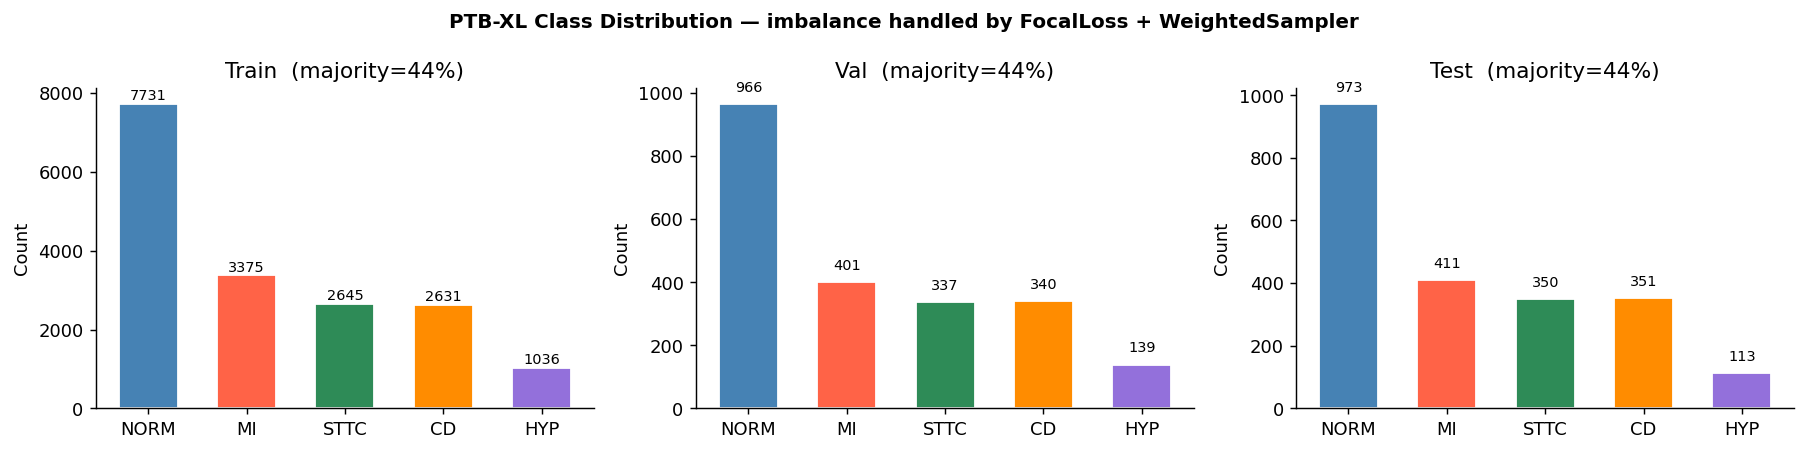

Class weights:
  NORM  count= 7731  IR=1.0x  w=0.451
  MI    count= 3375  IR=2.3x  w=1.032
  STTC  count= 2645  IR=2.9x  w=1.317
  CD    count= 2631  IR=2.9x  w=1.324
  HYP   count= 1036  IR=7.5x  w=3.363


In [ ]:
# VISUALIZE: Show the class imbalance problem
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

for ax, (split_y, name) in zip(axes, [(y_tr,'Train'),(y_val,'Val'),(y_te,'Test')]):
    counts = [(split_y==c).sum() for c in range(N_CLASSES)]
    bars   = ax.bar(CLASS_NAMES, counts, color=CLASS_COLORS, edgecolor='white', width=0.6)
    
    # Add count labels on top of bars
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                str(cnt), ha='center', va='bottom', fontsize=8)
    
    majority_pct = max(counts) / sum(counts) * 100
    ax.set_title(f'{name} - {majority_pct:.0f}% is just one class!')
    ax.set_ylabel('# of recordings')

plt.suptitle('Problem: Class Imbalance\nWe fix this with FocalLoss + Weighted Sampling', 
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/00_class_imbalance.png', bbox_inches='tight')
plt.show()

# CALCULATE: Class weights for balancing
# Formula: weight = (total samples) / (num classes * samples in this class)
# Rare classes get higher weight, common classes get lower weight
class_counts_tr  = np.bincount(y_tr, minlength=N_CLASSES).astype(np.float32)
class_weights_np = class_counts_tr.sum() / (N_CLASSES * class_counts_tr)
class_weights    = torch.tensor(class_weights_np, dtype=torch.float32)
sample_weights   = class_weights[y_tr]
sampler_tr       = WeightedRandomSampler(sample_weights, len(y_tr), replacement=True)

print('Class Weights (for balancing):')
for i,(name,w) in enumerate(zip(CLASS_NAMES, class_weights_np)):
    count = int(class_counts_tr[i])
    imbalance_ratio = class_counts_tr.max() / class_counts_tr[i]
    print(f'  {name:4s}: {count:5d} recordings, imbalance ratio={imbalance_ratio:4.1f}x, weight={w:.3f}')


## Section 4 – Create DataLoaders (Prepare Data for Training)

**What's a DataLoader?** 
Think of it like a cafeteria line:
- You have 21,837 recordings to train on
- You can't process them all at once (too much memory)
- So you take 32 at a time (batch size = 32)
- For training, shuffle the order and apply data augmentation
- For validation/test, just read in order without changing anything

**ECGDatasetV10** - Our custom dataset class that:
- Reads ECG from the memmap (memory-safe)
- Normalizes each sensor independently
- Applies augmentation for training (add noise, stretch, drop channels) to prevent overfitting

In [ ]:
class ECGDatasetV10(Dataset):
    """
    Load ECG recordings with on-the-fly normalization and augmentation.
    Works for both 100 Hz and 500 Hz via FREQ_HZ setting.
    """
    def __init__(self, mmap_arr, indices, labels_arr, augment=False):
        self.mmap    = mmap_arr  # The big file with all ECGs (memmap)
        self.indices = indices   # Which recordings to use (train/val/test)
        self.labels  = labels_arr  # Disease label for each recording
        self.augment = augment   # If True, add random noise/changes (training only)

    def __len__(self):
        """How many recordings in this dataset?"""
        return len(self.indices)

    def __getitem__(self, i):
        """Get ONE recording and its label."""
        
        # Step 1: Read raw ECG from disk (12 sensors, RAW_LEN time points)
        raw = self.mmap[self.indices[i]].copy()
        raw64 = raw.astype(np.float64)
        
        # Step 2: Normalize each sensor independently
        # (mean=0, std=1, so all sensors are on same scale)
        mu  = raw64.mean(axis=0, keepdims=True)
        std = np.clip(raw64.std(axis=0, keepdims=True), 1e-6, None)
        raw = ((raw64 - mu) / std).astype(np.float32)
        
        # Step 3: Convert to torch and transpose to (channels, time)
        x = torch.from_numpy(raw.T).unsqueeze(0)  # (1, 12, RAW_LEN)
        
        # Step 4: If we collected at 500 Hz but want 100 Hz data, interpolate down
        if RAW_LEN != NORMALIZE_LEN:
            x = F.interpolate(x, size=NORMALIZE_LEN, mode='linear',
                              align_corners=False)
        
        x = x.squeeze(0)  # Remove the 1 dimension -> (12, NORMALIZE_LEN)
        
        # Step 5: If training, add random augmentation (make model more robust)
        if self.augment:
            x = ECGDatasetV10._aug(x)
        
        return x, self.labels[i]

    @staticmethod
    def _aug(x):
        """
        Data Augmentation: Add realistic variations to ECG signals
        (Models trained on varied data generalize better)
        """
        C, T = x.shape
        
        # Random amplitude scaling: 80%-120% of original
        x = x * (0.80 + 0.40 * torch.rand(C, 1))
        
        # Add small random noise (2% of signal)
        x = x + torch.randn_like(x) * 0.02
        
        # Sometimes add sine wave drift (baseline wander - common in real ECGs)
        if torch.rand(1).item() > 0.60:
            freq  = 0.05 + 0.45 * torch.rand(1).item()  # 0.05-0.5 Hz
            t     = torch.arange(T, dtype=torch.float32) / float(FREQ_HZ)
            phase = 2.0 * math.pi * torch.rand(1).item()
            amp   = 0.05 + 0.15 * torch.rand(1).item()  # 5-15% amplitude
            x = x + (amp * torch.sin(2.0 * math.pi * freq * t + phase)).unsqueeze(0)
        
        # Sometimes drop one or two sensors (simulate sensor failure)
        if torch.rand(1).item() > 0.65:
            drop = torch.randperm(C)[:torch.randint(1, 4, (1,)).item()]
            x[drop] = 0.0
        
        # Sometimes mask out (hide) a chunk of time points
        mlen = int(T * 0.08 * torch.rand(1).item())  # Up to 8% of recording
        if mlen > 2:
            st = torch.randint(0, T - mlen, (1,)).item()
            x[:, st:st + mlen] = 0.0
        
        return x

    @staticmethod
    def aug_batch(x):
        """Batch version of augmentation (faster than per-sample)."""
        B, C, T = x.shape
        x = x * (0.80 + 0.40 * torch.rand(B, C, 1, device=x.device))
        x = x + torch.randn_like(x) * 0.02
        
        mask = torch.rand(B) > 0.60
        if mask.any():
            freq  = 0.05 + 0.45 * torch.rand(B, device=x.device)
            t     = torch.arange(T, dtype=torch.float32, device=x.device) / float(FREQ_HZ)
            phase = 2.0 * math.pi * torch.rand(B, device=x.device)
            amp   = 0.05 + 0.15 * torch.rand(B, device=x.device)
            wander = amp.unsqueeze(1) * torch.sin(
                2.0 * math.pi * freq.unsqueeze(1) * t.unsqueeze(0) + phase.unsqueeze(1))
            x[mask] = x[mask] + wander[mask].unsqueeze(1)
        
        for b in range(B):
            if torch.rand(1).item() > 0.65:
                drop = torch.randperm(C)[:torch.randint(1, 4, (1,)).item()]
                x[b, drop] = 0.0
        
        mlen = int(T * 0.08 * torch.rand(1).item())
        if mlen > 2:
            st = torch.randint(0, T - mlen, (1,)).item()
            x[:, :, st:st + mlen] = 0.0
        
        return x


# Create the three dataloaders
def make_loaders():
    train_ds = ECGDatasetV10(signals_mmap, tr_idx,  y_tr,  augment=True)   # Training: use augmentation
    val_ds   = ECGDatasetV10(signals_mmap, val_idx, y_val, augment=False)  # Validation: no augmentation
    test_ds  = ECGDatasetV10(signals_mmap, te_idx,  y_te,  augment=False)  # Test: no augmentation
    
    train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler_tr,
                          num_workers=0, pin_memory=torch.cuda.is_available())
    val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())
    test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=torch.cuda.is_available())
    return train_dl, val_dl, test_dl

train_dl, val_dl, test_dl = make_loaders()

print('DataLoaders created!')
print(f'  Train batches: {len(train_dl)} (batch size = {BATCH_SIZE})')
print(f'  Val batches:   {len(val_dl)}')
print(f'  Test batches:  {len(test_dl)}')

# Sanity check: make sure data looks right
x0, y0 = next(iter(train_dl))
print(f'\nFirst batch shapes:')
print(f'  ECGs (x): {x0.shape}  (batch=32, sensors=12, time points=1000)')
print(f'  Labels (y): {y0.shape}')
print(f'\nNormalization check (should be ~0 mean, ~1 std):')
print(f'  Mean: {x0.mean():.5f}')
print(f'  Std:  {x0.std():.5f}')


Train batches : 545
Val batches   : 69
Test batches  : 69
Batch shape   : x=torch.Size([32, 12, 1000])  y=torch.Size([32])
Norm check    : mean=-0.0010  std=0.9443


## Section 5 – Build the Model: InterpGN v10 (Interpretable + Accurate)

**Big Idea:** Use TWO experts and combine them:
1. **Interpretable Expert (Shapelet-Based)**: Understands patterns humans recognize
2. **Accurate Expert (ResNet1d)**: Uses deep learning to find hidden patterns

A "Gini gate" decides how much to trust each expert.

### Why Two Experts?

**Interpretable approach** (Shapelets):
- ✓ Can explain decisions: "I detected pattern X on sensor Y"
- ✗ Accuracy limited to hand-crafted patterns

**Deep learning approach** (ResNet):
- ✓ Can find any pattern if you give it enough data
- ✗ Can't explain why it made a decision

**Our solution:** Let them work together! When data is clear (high confidence), use the interpretable one. When uncertain, blend in the deep expert.

### Example Math: Simple Pattern Matching

Imagine looking for one specific pattern (shapelet = "abnormal dip"):
```
ECG sensor reading:  [1.0, 2.5, 3.1, 2.8, 1.2, 0.5, -0.2, 1.3, 2.0, 1.8]
Pattern we look for: [      2.5, 3.0, 2.7]

We slide the pattern across and measure how close it matches:
  Position 1: match score = sqrt((2.5-2.5)² + (3.1-3.0)² + (2.8-2.7)²) = 0.14
  Position 2: match score = sqrt((3.1-2.5)² + (2.8-3.0)² + (1.2-2.7)²) = 1.74
  Position 3: match score = sqrt((2.8-2.5)² + (1.2-3.0)² + (0.5-2.7)²) = 3.20
  ...

Best match = 0.14 at position 1.
High match = pattern is present.
```

We do this for 10 patterns per sensor per scale = 720 total features!

In [12]:
# FOCAL LOSS: Handle imbalanced data by focusing on hard examples
# 
# Problem: Normal accuracy (Cross-Entropy) treats all errors equally.
# If we have 95% healthy and 5% disease, model learns: "just guess healthy"
# and gets 95% accuracy without trying!
#
# Solution: Give MORE penalty to hard examples (rare classes)
# Formula: Loss = -α_t * (1 - p_t)^γ * log(p_t)
# where:
#   p_t = model's confidence in correct class
#   γ = focus parameter (we use 2)
#   If model is confused (p_t = 0.5), factor = 0.5^2 = 0.25 (penalty!)
#   If model is confident (p_t = 0.99), factor = 0.01^2 = 0.0001 (ignore, it's easy)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma  = gamma
        self.weight = weight  # Class weights for imbalance

    def forward(self, logits, targets):
        """Calculate focal loss for a batch."""
        log_p = F.log_softmax(logits, dim=-1)  # Convert logits to log-probabilities
        p_t   = log_p.exp().gather(1, targets.unsqueeze(1)).squeeze(1)  # P(correct class)
        focal = (1.0 - p_t).pow(self.gamma)  # Focus factor: low for confident, high for uncertain
        w     = self.weight.to(logits.device) if self.weight is not None else None
        ce    = F.nll_loss(log_p, targets, weight=w, reduction='none')  # Cross-entropy
        return (focal * ce).mean()  # Combine focal factor with cross-entropy

focal_loss = FocalLoss(gamma=FOCAL_GAMMA, weight=class_weights)
print('FocalLoss created!')
print('  Class weights:', class_weights_np.round(3))
print('  (Rare classes get higher weight, common classes get lower weight)')


FocalLoss ready. class_weights: [0.451 1.032 1.317 1.324 3.363]


In [ ]:
# ResNet1d: The Deep Learning Expert
# 
# What is ResNet?
# Think of it like layers in a painting:
#   1. Bottom layer: Detect tiny features (bumps, curves)
#   2. Middle layer: Detect medium features (small waves)
#   3. Top layer: Detect high-level patterns (arrhythmia signature)
#
# The "Res" stands for "Residual" - a skip connection.
# Instead of just:  output = f(input)
# We use:           output = f(input) + input
# This helps training - gradients can skip over layers!
#
# Architecture:
# Input (12 sensors, 1000 points)
#   ↓ Stem: Conv1d to get 64 features
#   ↓ Layer1: 2 ResBlocks (same size)
#   ↓ Layer2: 2 ResBlocks (half size) - start compressing
#   ↓ Layer3: 2 ResBlocks (quarter size) - compress more
#   ↓ Global Average Pool (take mean)
#   ↓ Linear layer (5 classes)
# Output: 5 disease probabilities
#
# This architecture was proven best for ECG in Strodthoff et al. 2020 paper

class ResBlock1d(nn.Module):
    """
    One Residual Block (building block of ResNet).
    
    If input channels = output channels AND stride = 1:
        output = ReLU(BN(Conv2(ReLU(BN(Conv1(input))))) + input)
    
    Otherwise, use a 1x1 conv to resize the skip connection.
    """
    def __init__(self, in_ch, out_ch, kernel=7, stride=1, dropout=0.1):
        super().__init__()
        pad = kernel // 2
        
        # Main path: Conv → BatchNorm → Conv → BatchNorm
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, stride=stride,
                               padding=pad, bias=False)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, stride=1,
                               padding=pad, bias=False)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        
        # Skip connection: if sizes don't match, use 1x1 conv to resize
        self.skip  = (nn.Sequential(
                          nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                          nn.BatchNorm1d(out_ch))
                      if (in_ch != out_ch or stride != 1) else nn.Identity())

    def forward(self, x):
        # Main path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        
        # Add skip connection
        return F.relu(out + self.skip(x))


class ResNet1d(nn.Module):
    """
    ResNet1d: Deep expert for accurate ECG classification.
    Stores activations and gradients for Grad-CAM visualization.
    """
    def __init__(self, n_channels=12, n_classes=5):
        super().__init__()
        
        # Stem: Initial convolution (12 → 64 features, compress time by 2)
        self.stem = nn.Sequential(
            nn.Conv1d(n_channels, 64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU())

        # Layer 1: Two ResBlocks (64 features, no compression)
        self.layer1 = nn.Sequential(
            ResBlock1d(64,  64,  kernel=7, stride=1),
            ResBlock1d(64,  64,  kernel=7, stride=1))

        # Layer 2: Two ResBlocks (64→128 features, compress time by 2)
        self.layer2 = nn.Sequential(
            ResBlock1d(64,  128, kernel=5, stride=2),
            ResBlock1d(128, 128, kernel=5, stride=1))

        # Layer 3: Two ResBlocks (128→256 features, compress time by 2)
        # ← We hook Grad-CAM here (last feature map)
        self.layer3 = nn.Sequential(
            ResBlock1d(128, 256, kernel=3, stride=2),
            ResBlock1d(256, 256, kernel=3, stride=1))

        # Head: Compress to 5 disease predictions
        self.gap = nn.AdaptiveAvgPool1d(1)  # Take mean across time
        self.fc  = nn.Linear(256, n_classes)  # Final classification

        # Grad-CAM storage (for visualization)
        self._grad_cam_acts  = None
        self._grad_cam_grads = None
        self._gc_fwd_hook    = None
        self._gc_bwd_hook    = None

    def forward(self, x):
        """Forward pass through the network."""
        x = self.stem(x)        # 12 → 64 features, time/2
        x = self.layer1(x)      # Stay 64 features
        x = self.layer2(x)      # 64 → 128 features, time/2
        x = self.layer3(x)      # 128 → 256 features, time/2  [Grad-CAM target]
        x = self.gap(x).squeeze(-1)  # Compress: (B, 256, T) → (B, 256)
        return self.fc(x)       # 256 → 5 classes

    # ─── Grad-CAM: Visualize what the model looked at ───────────────────────
    
    def register_grad_cam_hooks(self):
        """Capture activations and gradients from layer3 for visualization."""
        self.remove_grad_cam_hooks()
        
        def fwd_hook(module, inp, out):
            """Save the output of layer3."""
            self._grad_cam_acts = out.detach()
        
        def bwd_hook(module, grad_in, grad_out):
            """Save the gradient flowing back through layer3."""
            self._grad_cam_grads = grad_out[0].detach()
        
        # Attach hooks
        self._gc_fwd_hook = self.layer3.register_forward_hook(fwd_hook)
        self._gc_bwd_hook = self.layer3.register_full_backward_hook(bwd_hook)

    def remove_grad_cam_hooks(self):
        """Clean up hooks (important to avoid memory leaks)."""
        if self._gc_fwd_hook  is not None: 
            self._gc_fwd_hook.remove()
            self._gc_fwd_hook  = None
        if self._gc_bwd_hook  is not None: 
            self._gc_bwd_hook.remove()
            self._gc_bwd_hook  = None

    @torch.enable_grad()
    def grad_cam(self, x, class_idx=None):
        """
        Compute Grad-CAM: Visual explanation of model decisions.
        
        Shows which TIME POINTS (in the ECG) influenced the prediction.
        Red = important for prediction, Blue = not important.
        
        Returns: (B, NORMALIZE_LEN) saliency map (same shape as input)
        """
        self.register_grad_cam_hooks()
        self.eval()
        
        # Forward pass
        x_in = x.clone().requires_grad_(False)
        logits = self.forward(x_in)
        
        # Pick class to visualize (highest prediction by default)
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
        
        # Sum the target class scores (so gradient flows back through them)
        scores = logits[torch.arange(len(logits)), class_idx].sum()
        
        # Backward pass (compute gradients)
        self.zero_grad()
        scores.backward()

        # Combine activations (what features were detected)
        # and gradients (which features matter for the decision)
        acts  = self._grad_cam_acts                          # (B, 256, T')
        grads = self._grad_cam_grads                         # (B, 256, T')
        
        # Average gradient per feature channel
        weights = grads.mean(dim=-1, keepdim=True)           # (B, 256, 1)
        
        # Weighted combination of activations
        cam = F.relu((weights * acts).sum(dim=1, keepdim=True))  # (B, 1, T')
        
        # Upsample back to original ECG resolution
        cam = F.interpolate(cam, size=x.shape[-1], mode='linear',
                            align_corners=False).squeeze(1)    # (B, T)
        
        # Normalize to [0, 1] for each sample
        mn = cam.amin(dim=1, keepdim=True)
        mx = cam.amax(dim=1, keepdim=True)
        cam = (cam - mn) / (mx - mn + 1e-8)
        
        self.remove_grad_cam_hooks()
        return cam.detach().cpu()

print('ResNet1d defined!')

# Sanity check: Make sure the output shapes are correct
_dummy = torch.zeros(2, N_CHANNELS, NORMALIZE_LEN)
_resnet_test = ResNet1d(N_CHANNELS, N_CLASSES)
_out = _resnet_test(_dummy)
total_params = sum(p.numel() for p in _resnet_test.parameters())

print(f'\nResNet1d Shapes:')
print(f'  Input:  {_dummy.shape}')
print(f'  Output: {_out.shape}')
print(f'  Params: {total_params:,}')
del _dummy, _resnet_test, _out


ResNet1d defined.
ResNet1d output: torch.Size([2, 5])
ResNet1d params: 1,147,781  (vs FCN-Wang ~134k in v9)


In [ ]:
# STRAIGHT-THROUGH ESTIMATOR: Gradient trick for discrete operations
# 
# Problem: Picking the MAX is not differentiable (gradient = 0 everywhere)
# Solution: In forward, use max (discrete). In backward, pretend we used softmax (smooth).
# This lets the model learn which patterns are important!

class STMax(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, dim):
        """Forward: Pick the maximum value."""
        ctx.save_for_backward(x)
        ctx.dim = dim
        return x.max(dim=dim).values
    
    @staticmethod
    def backward(ctx, grad_out):
        """Backward: Pretend we used softmax (so gradient doesn't die)."""
        x, = ctx.saved_tensors
        soft = F.softmax(x, dim=ctx.dim)
        return grad_out.unsqueeze(ctx.dim) * soft, None

def st_max(x, dim):
    return STMax.apply(x, dim)


# SHAPELET-BASED MODEL: Interpretable Pattern Matching
# 
# What's a Shapelet?
# → A small waveform pattern that's predictive of a disease
# → Like: "sudden drop followed by spike = heart attack"
#
# Why multiple scales?
# → Small patterns (length 50ms): Detect fine details
# → Medium patterns (length 100ms): Detect medium features
# → Large patterns (length 800ms): Detect overall shape
#
# How it works:
# 1. For each pattern, slide it across the ECG signal
# 2. Measure how close it matches at each position (Euclidean distance)
# 3. Keep the best (closest) match
# 4. Convert to probability: closer = higher confidence pattern exists
#
# Memory trick: Instead of computing all distances at once (2.3 GB!),
# use: ||w - s||² = ||w||² - 2<w,s> + ||s||²
# This is mathematically equivalent but uses 100x less memory!

class ShapeletLayer(nn.Module):
    """
    Detect ONE scale of patterns.
    E.g., one 200ms time window across all 12 sensors and 10 patterns.
    """
    def __init__(self, n_channels, n_shapelets, shapelet_len, eps_rbf=1.0):
        super().__init__()
        # Learnable patterns: shape = (12 sensors, 10 patterns, len)
        self.shapelet = nn.Parameter(
            torch.randn(n_channels, n_shapelets, shapelet_len) * 0.1)
        self.eps_rbf  = eps_rbf  # Sensitivity of pattern matching
        self.L        = shapelet_len

    def forward(self, x):
        """
        Input: x of shape (B, 12, 1000)  [batch, sensors, time]
        Output: shape (B, 120)  [batch, 12 sensors × 10 patterns]
        Each value is 0-1: how much this pattern exists in this recording
        """
        B, C, T = x.shape
        L, K    = self.L, self.shapelet.shape[1]

        # Precompute ||s||² (constant, doesn't change per batch)
        s2 = (self.shapelet ** 2).sum(-1)   # (C, K)

        p_list = []
        for c in range(C):
            # Process one sensor at a time to save memory
            xc = x[:, c:c+1, :]            # One sensor: (B, 1, T)
            sc = self.shapelet[c]           # 10 patterns for this sensor: (K, L)

            # STEP 1: Cross-correlation <window, shapelet>
            # This is the inner product between each sliding window and each pattern
            xcorr = F.conv1d(xc, sc.unsqueeze(1))   # (B, K, T-L+1)

            # STEP 2: Compute ||window||² using cumulative sum trick
            # Avoids allocating huge (B, K, T-L+1, L) tensor
            x2    = xc.squeeze(1) ** 2              # (B, T)
            cs    = F.pad(x2.cumsum(-1), (1, 0))    # (B, T+1)
            win2  = cs[:, L:] - cs[:, :-L]          # (B, T-L+1)

            # STEP 3: Compute full distance: d² = ||w||² - 2<w,s> + ||s||²
            d2 = (win2.unsqueeze(1)               # (B, 1, T-L+1)
                  - 2.0 * xcorr                   # (B, K, T-L+1)
                  + s2[c].view(1, K, 1)           # (1, K, 1)
                  ).clamp(min=0)                  # Prevent negative due to float errors

            # STEP 4: Keep best (minimum) distance
            d_min = st_max(-d2, dim=-1)           # (B, K)

            # STEP 5: Convert distance to probability
            # Small distance (close match) → high probability
            p_c = torch.exp(self.eps_rbf * d_min)
            p_list.append(p_c)

        return torch.cat(p_list, dim=1)     # (B, C*K) = (B, 120)


class SBM(nn.Module):
    """
    Shapelet-Based Model (Interpretable Branch).
    
    What it does:
    1. Extract shapelet features at 6 different time scales
    2. Linear classifier on top
    3. Loss includes: classification + pattern diversity + pattern simplicity
    """
    def __init__(self, n_channels, n_classes, shapelet_lens, k_shapelets,
                 eps_rbf=1.0, lambda_div=0.1, lambda_reg=0.1):
        super().__init__()
        
        # One ShapeletLayer per scale
        self.shapelet_layers = nn.ModuleList([
            ShapeletLayer(n_channels, k_shapelets, L, eps_rbf)
            for L in shapelet_lens])
        
        # Total features = 12 sensors × 10 patterns × 6 scales = 720
        self._n_feats    = n_channels * k_shapelets * len(shapelet_lens)
        
        # Simple linear classifier on shapelet features
        self.classifier  = nn.Linear(self._n_feats, n_classes)
        
        # Loss weights
        self.lambda_div  = lambda_div   # Penalty for duplicate patterns
        self.lambda_reg  = lambda_reg   # Penalty for complex patterns
        self._focal      = FocalLoss(FOCAL_GAMMA, class_weights)

    def forward(self, x):
        """
        Forward pass: extract all shapelet features and classify.
        """
        # Extract features from all 6 scales and concatenate
        feats  = torch.cat([sl(x) for sl in self.shapelet_layers], dim=1)
        logits = self.classifier(feats)
        return logits, feats

    def sbm_loss(self, logits, targets):
        """
        Loss = Classification Loss + Diversity Loss + Regularization
        
        Classification: FocalLoss (handles imbalance)
        Diversity: Penalize if two patterns are too similar
        Regularization: Penalize if patterns are too wiggly/complex
        """
        # TERM 1: Classification loss
        l_focal = self._focal(logits, targets)
        
        # TERM 2: Diversity loss
        # If two weight columns are highly correlated, penalize
        W  = self.classifier.weight               # (5 classes, 720 features)
        Wn = F.normalize(W, p=2, dim=0)           # Normalize each feature
        corr = (Wn.T @ Wn).abs()                  # Correlation matrix: (720, 720)
        corr.fill_diagonal_(0)                     # Ignore self-correlation
        l_div = corr.mean()                        # Average correlation
        
        # TERM 3: Regularization - keep patterns simple
        l_reg = sum(sl.shapelet.abs().mean() for sl in self.shapelet_layers)
        
        return l_focal + self.lambda_div * l_div + self.lambda_reg * l_reg


# GINI GATE: Decide how much to trust the interpretable model
#
# Why? The interpretable model and the deep model have different strengths:
# - When ECG is CLEAR: interpretable model is confident + interpretable
# - When ECG is AMBIGUOUS: deep model can find subtle patterns
#
# The gate uses a GINI coefficient to measure confidence:
# - Gini = 0: model is uncertain (all classes equally likely)
# - Gini = 1: model is very confident (one class has 100%)
#
# High Gini → Trust interpretable (we understand why)
# Low Gini  → Trust deep model (it might see something we don't)

def gini_gate(sbm_logits, n_classes):
    """
    Measure confidence of SBM predictions using Gini impurity.
    Returns: eta in [0, 1]
      η = 1: very confident (use SBM)
      η = 0: very uncertain (use ResNet)
    """
    r_hat = F.softmax(sbm_logits, dim=-1)  # (B, 5) probabilities
    # Gini = 1 - Σ(p_i²)  normalized to [0,1]
    eta   = n_classes * ((r_hat ** 2).sum(dim=-1) - 1.0 / n_classes) / (n_classes - 1)
    return eta.clamp(0, 1)


# FINAL MODEL: InterpGN v10
#
# Architecture:
#   Input ECG (12 sensors, 1000 points)
#   ├─ SBM (Interpretable):   → 720 features → logits → [0, 1, 2, 3, 4]
#   └─ ResNet1d (Accurate):   → 256 features → logits → [0, 1, 2, 3, 4]
#
#   Gini Gate: measures SBM confidence
#   Output: η * sbm_logits + (1-η) * resnet_logits
#
# Example:
#   SBM: [0.8, 0.1, 0.05, 0.05, 0.0]  (says "definitely class 0")
#   ResNet: [0.7, 0.2, 0.05, 0.03, 0.02]  (also says "class 0")
#   Gini = 0.9 (very confident)
#   η = 0.9 → Output = 0.9*SBM + 0.1*ResNet (mostly trust SBM + can explain)
#
# If they disagree:
#   SBM: [0.4, 0.4, 0.1, 0.1, 0.0]  (uncertain, 50-50 split)
#   ResNet: [0.2, 0.05, 0.65, 0.05, 0.05]  (says "class 2")
#   Gini = 0.3 (uncertain)
#   η = 0.3 → Output = 0.3*SBM + 0.7*ResNet (mostly trust ResNet's reasoning)

class InterpGNv10(nn.Module):
    """
    Hybrid model: Interpretable SBM + Accurate ResNet + Smart blending.
    """
    def __init__(self, n_channels=12, n_classes=5,
                 shapelet_lens=SHAPELET_LENS, k_shapelets=K_SHAPELETS,
                 eps_rbf=EPSILON_RBF, lambda_div=LAMBDA_DIV,
                 lambda_reg=LAMBDA_REG):
        super().__init__()
        self.sbm    = SBM(n_channels, n_classes, shapelet_lens, k_shapelets,
                          eps_rbf, lambda_div, lambda_reg)
        self.resnet = ResNet1d(n_channels, n_classes)
        self.n_classes = n_classes

    def forward(self, x, x_aug=None):
        """
        Forward pass with optional augmented input for ResNet.
        """
        # Interpretable branch
        sbm_logits, predicates = self.sbm(x)
        
        # Accurate branch (can use augmented version)
        resnet_in   = x_aug if x_aug is not None else x
        res_logits  = self.resnet(resnet_in)
        
        # Measure confidence of SBM
        eta = gini_gate(sbm_logits, self.n_classes)  # (B,) in [0, 1]
        
        # Blend: high eta = trust SBM, low eta = trust ResNet
        joint = (eta.unsqueeze(1) * sbm_logits
                 + (1.0 - eta).unsqueeze(1) * res_logits)
        
        return {'logits'     : joint,           # Final prediction
                'sbm_logits' : sbm_logits,      # Interpretable prediction
                'res_logits' : res_logits,      # Deep prediction
                'gate'       : eta,              # Confidence level
                'predicates' : predicates}       # Detected patterns

    def forward_inference(self, x):
        """Use at test time (no augmentation)."""
        return self.forward(x, x_aug=None)

# Create the model
model = InterpGNv10().to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
sbm_p   = sum(p.numel() for p in model.sbm.parameters())
res_p   = sum(p.numel() for p in model.resnet.parameters())

print('✓ Model built!')
print(f'\n  Total parameters: {total_params:,}')
print(f'    - SBM (Interpretable): {sbm_p:,}')
print(f'    - ResNet1d (Accurate): {res_p:,}')
print(f'\n  Device: {DEVICE}')
print(f'  Model is on GPU: {next(model.parameters()).is_cuda}')


InterpGN v10 total params : 1,385,386
  SBM params              : 237,605
  ResNet1d params         : 1,147,781


In [24]:
# ── ShapeletLayer v2 — fully vectorised, no Python channel loop ───────────────
#
# Speed fix: replace the `for c in range(C)` loop with F.conv1d(groups=C).
#
# groups=C means: apply K filters to channel c, independently per channel.
# One CUDA kernel handles all C channels simultaneously.
#
# Memory per scale (L=800, B=32):
#   xcorr (B, C, K, T-L+1) = 32×12×10×201×4 B ≈ 30 MB   (vs 2.3 GB before)
#   d2    same shape        ≈ 30 MB
# Total across 6 scales ≈ 360 MB  —  fine on 6 GB VRAM
# ─────────────────────────────────────────────────────────────────────────────

class ShapeletLayer(nn.Module):
    def __init__(self, n_channels, n_shapelets, shapelet_len, eps_rbf=1.0):
        super().__init__()
        self.shapelet = nn.Parameter(
            torch.randn(n_channels, n_shapelets, shapelet_len) * 0.1)
        self.eps_rbf  = eps_rbf
        self.C, self.K, self.L = n_channels, n_shapelets, shapelet_len

    def forward(self, x):
        B, C, T = x.shape
        K, L    = self.K, self.L

        # ── ⟨window, shapelet⟩ via grouped conv ─────────────────────────────
        # weight shape for groups=C:  (C*K, 1, L)
        w     = self.shapelet.view(C * K, 1, L)
        xcorr = F.conv1d(x, w, groups=C)           # (B, C*K, T-L+1)
        xcorr = xcorr.view(B, C, K, -1)            # (B, C, K, T-L+1)

        # ── ‖window‖² via cumsum  (O(T) memory, fully vectorised) ───────────
        x2   = x ** 2                              # (B, C, T)
        cs   = F.pad(x2.cumsum(-1), (1, 0))        # (B, C, T+1)
        win2 = (cs[:, :, L:] - cs[:, :, :-L]
                ).unsqueeze(2)                     # (B, C, 1, T-L+1)

        # ── ‖shapelet‖² — (1, C, K, 1) ──────────────────────────────────────
        s2 = (self.shapelet ** 2).sum(-1).view(1, C, K, 1)

        # ── d² = ‖w‖² − 2⟨w,s⟩ + ‖s‖²  ─────────────────────────────────────
        d2    = (win2 - 2.0 * xcorr + s2).clamp(min=0)   # (B, C, K, T-L+1)
        d_min = st_max(-d2, dim=-1)                        # (B, C, K)
        p     = torch.exp(self.eps_rbf * d_min)            # (B, C, K)
        return p.view(B, C * K)                            # (B, C*K)

## Section 5b – Initialize Shapelet Patterns using K-Means

**What we do:** Instead of starting with random patterns, we use smart initialization:
1. Sample 1500 random ECG recordings from training set
2. Extract small windows from them (these are potential pattern candidates)
3. Use k-means clustering to find 10 representative patterns per scale
4. Use these as the starting point for training

**Why?** Better initialization = faster training = better final accuracy

In [ ]:
@torch.no_grad()
def init_shapelets_kmeans(mmap_arr, indices, n_channels, n_shapelets,
                          shapelet_len, n_samples=1500, seed=42):
    """
    Initialize shapelet patterns using k-means clustering.
    
    Steps:
    1. Sample 1500 recordings
    2. Extract all small windows of length shapelet_len
    3. Run k-means to find 10 representative patterns
    4. Use as initialization for the learnable shapelet parameters
    """
    rng    = np.random.default_rng(seed)
    samp   = rng.choice(indices, min(n_samples, len(indices)), replace=False)
    stride = max(1, int(math.log(max(shapelet_len, 2))))  # Sparse sampling

    wins_per_ch = [[] for _ in range(n_channels)]
    
    # Extract windows from all sampled recordings
    for idx in samp:
        raw   = mmap_arr[idx].copy().astype(np.float64)
        mu    = raw.mean(axis=0, keepdims=True)
        std   = np.clip(raw.std(axis=0, keepdims=True), 1e-6, None)
        raw   = ((raw - mu) / std).astype(np.float32)  # Normalize

        x = torch.from_numpy(raw.T).unsqueeze(0)
        if RAW_LEN != NORMALIZE_LEN:
            x = F.interpolate(x, size=NORMALIZE_LEN, mode='linear',
                              align_corners=False)
        x = x.squeeze(0)

        # Extract sliding windows for each channel
        for ch in range(n_channels):
            sig  = x[ch].numpy()
            wins = np.lib.stride_tricks.sliding_window_view(sig, shapelet_len)[::stride]
            mu_w = wins.mean(-1, keepdims=True)
            sd_w = np.clip(wins.std(-1, keepdims=True), 1e-6, None)
            wins_per_ch[ch].append((wins - mu_w) / sd_w)  # Normalize each window

    # Run k-means clustering on each channel separately
    init = np.zeros((n_channels, n_shapelets, shapelet_len), dtype=np.float32)
    for ch in range(n_channels):
        W = np.concatenate(wins_per_ch[ch], axis=0)  # All windows for this channel
        
        # Limit to 20k windows to speed up k-means
        if len(W) > 20000:
            W = W[rng.choice(len(W), 20000, replace=False)]
        
        # k-means: find 10 cluster centers (the patterns)
        km = MiniBatchKMeans(n_clusters=n_shapelets, random_state=seed,
                             n_init=5, max_iter=150, batch_size=2048)
        km.fit(W)
        init[ch] = km.cluster_centers_.astype(np.float32)
    
    return init

print('Computing k-means shapelet initializations...')
shapelet_inits = {}
for i, L in enumerate(SHAPELET_LENS):
    print(f'  Scale {i+1}/{len(SHAPELET_LENS)}  Pattern length={L} points ...', end=' ', flush=True)
    shapelet_inits[L] = init_shapelets_kmeans(
        signals_mmap, tr_idx, N_CHANNELS, K_SHAPELETS, L)
    print(f'✓ Shape: {shapelet_inits[L].shape}')

# Apply the k-means initialized patterns to our model
print('\nApplying k-means initialization to model...')
for sl, L in zip(model.sbm.shapelet_layers, SHAPELET_LENS):
    with torch.no_grad():
        sl.shapelet.copy_(torch.from_numpy(shapelet_inits[L]))

print('✓ Model initialized with smart pattern seeds!')


Computing k-means shapelet initialisations (~2-4 min)...
  Scale 1/6  L=50 ... done  shape=(12, 10, 50)
  Scale 2/6  L=100 ... done  shape=(12, 10, 100)
  Scale 3/6  L=200 ... done  shape=(12, 10, 200)
  Scale 4/6  L=300 ... done  shape=(12, 10, 300)
  Scale 5/6  L=500 ... done  shape=(12, 10, 500)
  Scale 6/6  L=800 ... done  shape=(12, 10, 800)
Shapelet k-means init applied.


## Section 6 – Training: 3 Phases with Early Stopping

**Why 3 phases?**
- **Phase 0**: Teach the SBM to recognize patterns (shapelets)
- **Phase 0b**: Teach the ResNet1d to recognize diseases accurately
- **Phase 1**: Train everything together, let them help each other

**Early Stopping:** Stop training if validation accuracy stops improving (to avoid overfitting)

**Learning Rate Schedule:** 
- Phases 0&0b: Cosine Annealing (smooth, steady learning)
- Phase 1: OneCycleLR (one big cycle - fast at start, slow at end)

In [ ]:
# EVALUATION FUNCTIONS: Measure how well the model performs
# ============================================================================

def evaluate(model, loader, device=DEVICE):
    """
    Test the model on a dataset (validation or test set).
    Returns: (accuracy, balanced_accuracy, predictions, true_labels)
    """
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for x, lbl in loader:
            x, lbl = x.to(device), lbl.to(device)
            out    = model.forward_inference(x)  # Get predictions
            preds  = out['logits'].argmax(-1)     # Pick highest class
            all_preds.append(preds.cpu())
            all_labels.append(lbl.cpu())
    
    p = torch.cat(all_preds).numpy()
    l = torch.cat(all_labels).numpy()
    
    # Regular accuracy: (# correct) / (# total)
    acc = (p == l).mean()
    
    # Balanced accuracy: average per-class accuracy (handles imbalance)
    # Why? If 95% are class 0, model can get 95% by just guessing 0!
    # Balanced = average of: P(correct | class 0) + P(correct | class 1) + ...
    bal_acc = balanced_accuracy_score(l, p)
    
    return acc, bal_acc, p, l

def evaluate_expert(model, loader, expert='sbm', device=DEVICE):
    """
    Test ONE expert in isolation (interpretable or deep).
    Returns: accuracy of that expert alone
    """
    model.eval()
    correct = total = 0
    
    with torch.no_grad():
        for x, lbl in loader:
            x, lbl = x.to(device), lbl.to(device)
            
            if expert == 'sbm':
                logits = model.sbm(x)[0]  # Get SBM output
            else:
                logits = model.resnet(x)   # Get ResNet output
            
            correct += (logits.argmax(-1) == lbl).sum().item()
            total   += lbl.size(0)
    
    return correct / total

def get_gate_stats(model, loader, device=DEVICE):
    """
    See how much the model trusts each expert on each example.
    Returns: (gate values, true labels)
    gate ≈ 1 → trust interpretable (SBM)
    gate ≈ 0 → trust deep (ResNet)
    """
    model.eval()
    gates, labels = [], []
    
    with torch.no_grad():
        for x, lbl in loader:
            out = model(x.to(device))
            gates.append(out['gate'].cpu().numpy())  # η values
            labels.append(lbl.numpy())
    
    return np.concatenate(gates), np.concatenate(labels)

print('✓ Evaluation functions defined')


Evaluation helpers defined.


In [ ]:
# EARLY STOPPING: Stop training when validation accuracy stops improving
# =========================================================================
# 
# Problem: If we train too long, the model memorizes the training data
#          and performs worse on validation/test (overfitting).
#
# Solution: Monitor validation accuracy. If it doesn't improve for N epochs,
#           stop training and go back to the best model we've seen.

class EarlyStopping:
    def __init__(self, patience=ES_PATIENCE, min_delta=ES_MIN_DELTA, path=None):
        """
        patience: How many epochs with no improvement before stopping (e.g., 20)
        min_delta: Minimum improvement to count (e.g., 0.0001)
        path: Where to save the best model
        """
        self.patience   = patience
        self.min_delta  = min_delta
        self.path       = path or f'{OUTPUTS_DIR}/interpgn_v10_best.pt'
        self.best_score = -np.inf
        self.counter    = 0  # Count epochs with no improvement
        self.stopped    = False
        self.best_epoch = 0

    def __call__(self, val_acc, model, epoch):
        """
        Check if validation accuracy improved.
        If yes: save model, reset counter
        If no: increment counter, stop if counter >= patience
        """
        if val_acc > self.best_score + self.min_delta:
            # Improvement! Save this model
            self.best_score = val_acc
            self.counter    = 0
            self.best_epoch = epoch
            torch.save(model.state_dict(), self.path)
        else:
            # No improvement
            self.counter += 1
            if self.counter >= self.patience:
                self.stopped = True
        
        return self.stopped

    def load_best(self, model, device=DEVICE):
        """Load the best model we found during training."""
        model.load_state_dict(torch.load(self.path, map_location=device))
        print(f'✓ Best model loaded from epoch {self.best_epoch+1} '
              f'(validation accuracy = {self.best_score:.4f})')

print('✓ EarlyStopping class defined')


EarlyStopping class defined.


In [ ]:
# SETUP FOR TRAINING
# =========================================================================

# Fresh model with good initialization
torch.cuda.empty_cache()
model = InterpGNv10().to(DEVICE)

# Apply the k-means initialized patterns
for sl, L in zip(model.sbm.shapelet_layers, SHAPELET_LENS):
    with torch.no_grad():
        sl.shapelet.copy_(torch.from_numpy(shapelet_inits[L]))

# Early stopping monitor
es = EarlyStopping()

# Check GPU memory
if torch.cuda.is_available():
    free  = torch.cuda.mem_get_info()[0] / 1e9
    total = torch.cuda.mem_get_info()[1] / 1e9
    print(f'GPU Memory: {free:.1f} GB free / {total:.1f} GB total')

# Sanity check: Make sure one batch runs quickly
print('\nSpeed sanity check...')
model.eval()
with torch.no_grad():
    x0, _ = next(iter(train_dl))
    import time
    t0 = time.time()
    _ = model.sbm(x0.to(DEVICE))
    torch.cuda.synchronize()
    elapsed_ms = (time.time() - t0) * 1000
    print(f'  SBM forward pass: {elapsed_ms:.0f} ms')
    print(f'  (Should be <500 ms for batch size 32)')


VRAM: 5.3 GB free / 6.4 GB total
SBM forward pass: 333 ms  (target: <500 ms for B=32)


In [ ]:
# ========================================================================
# PHASE 0: Train the Interpretable Model (SBM) Alone
# ========================================================================
# 
# Why? Train patterns one at a time before mixing with deep learning.
#      This lets SBM learn good features before being overshadowed by ResNet.
# 
# Loss = Classification (FocalLoss) + Diversity + Regularization

print('\n' + '='*70)
print('PHASE 0: SBM Pre-training ({} epochs)'.format(N_EPOCHS_PRE_SBM))
print('='*70)

opt_sbm   = torch.optim.Adam(model.sbm.parameters(), lr=LR)
sched_sbm = torch.optim.lr_scheduler.CosineAnnealingLR(opt_sbm, T_max=N_EPOCHS_PRE_SBM)

for epoch in range(N_EPOCHS_PRE_SBM):
    model.sbm.train()
    model.resnet.eval()
    
    ep_loss = 0.0
    
    # Training loop
    for x, lbl in train_dl:
        x, lbl = x.to(DEVICE), lbl.to(DEVICE)
        
        # Forward pass
        logits, _ = model.sbm(x)
        loss = model.sbm.sbm_loss(logits, lbl)
        
        # Backward pass
        opt_sbm.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.sbm.parameters(), 1.0)  # Prevent exploding gradients
        opt_sbm.step()
        
        ep_loss += loss.item()
    
    sched_sbm.step()  # Update learning rate
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        sbm_acc = evaluate_expert(model, val_dl, 'sbm')
        gn = sum(p.grad.norm().item() if p.grad is not None else 0 
                 for p in model.sbm.parameters())
        print(f'  Epoch {epoch+1:3d}/{N_EPOCHS_PRE_SBM}  '
              f'Loss={ep_loss/len(train_dl):.4f}  '
              f'SBM Val Acc={sbm_acc:.4f}  '
              f'Grad Norm={gn:.3f}')

print('✓ Phase 0 complete: SBM learned to extract patterns')


Phase 0: SBM pre-training
  ep  10/30  loss=0.8656  sbm_val_acc=0.4013  gnorm=0.801
  ep  20/30  loss=0.8120  sbm_val_acc=0.4430  gnorm=0.885
  ep  30/30  loss=0.7940  sbm_val_acc=0.4352  gnorm=0.955
SBM pre-training complete.


In [ ]:
# ========================================================================
# PHASE 0b: Train the Deep Model (ResNet1d) Alone
# ========================================================================
#
# Why? Train the deep learner next, so it doesn't overpower the SBM.
#      Both experts get trained before they meet (phase 1).
#
# Loss = FocalLoss (handles imbalance)
# Early stopping: Stop if validation accuracy doesn't improve

print('\n' + '='*70)
print('PHASE 0b: ResNet1d Pre-training ({} epochs)'.format(N_EPOCHS_PRE_FCN))
print('='*70)

opt_res   = torch.optim.Adam(model.resnet.parameters(),
                              lr=LR, weight_decay=WEIGHT_DECAY)
sched_res = torch.optim.lr_scheduler.CosineAnnealingLR(opt_res, T_max=N_EPOCHS_PRE_FCN)
es_res    = EarlyStopping(patience=8, path=f'{OUTPUTS_DIR}/resnet_pretrain_best.pt')

for epoch in range(N_EPOCHS_PRE_FCN):
    model.resnet.train()
    model.sbm.eval()
    
    ep_loss = 0.0
    
    # Training loop
    for x, lbl in train_dl:
        x, lbl = x.to(DEVICE), lbl.to(DEVICE)
        
        logits = model.resnet(x)
        loss   = focal_loss(logits, lbl)  # FocalLoss handles class imbalance
        
        opt_res.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.resnet.parameters(), 1.0)
        opt_res.step()
        
        ep_loss += loss.item()
    
    sched_res.step()
    
    # Print progress every 2 epochs
    if (epoch + 1) % 2 == 0:
        res_acc = evaluate_expert(model, val_dl, 'resnet')
        print(f'  Epoch {epoch+1:3d}/{N_EPOCHS_PRE_FCN}  '
              f'Loss={ep_loss/len(train_dl):.4f}  '
              f'ResNet Val Acc={res_acc:.4f}')
        
        # Early stopping
        if es_res(res_acc, model, epoch):
            print(f'  → Early stopping at epoch {epoch+1}')
            break

# Load best ResNet weights found
es_res.load_best(model)
print('✓ Phase 0b complete: ResNet learned accurate predictions')


Phase 0b: ResNet1d pre-training
  ep   2/25  loss=0.7837  resnet_val_acc=0.4137
  ep   4/25  loss=0.7107  resnet_val_acc=0.4049
  ep   6/25  loss=0.6498  resnet_val_acc=0.4883
  ep   8/25  loss=0.6119  resnet_val_acc=0.4370
  ep  10/25  loss=0.5634  resnet_val_acc=0.4498
  ep  12/25  loss=0.5318  resnet_val_acc=0.5163
  ep  14/25  loss=0.4901  resnet_val_acc=0.5025
  ep  16/25  loss=0.4294  resnet_val_acc=0.5525
  ep  18/25  loss=0.3959  resnet_val_acc=0.6294
  ep  20/25  loss=0.3574  resnet_val_acc=0.6377
  ep  22/25  loss=0.3395  resnet_val_acc=0.6450
  ep  24/25  loss=0.3260  resnet_val_acc=0.6212
Best model loaded (epoch 22, val_acc=0.6450)
ResNet1d pre-training complete.


In [ ]:
# ========================================================================
# PHASE 1: Joint Training (All Components Together)
# ========================================================================
#
# Now we blend both experts and train the whole model.
# 
# Key ideas:
# 1. Beta ramp: gradually increase trust in interpretability
#    - Early: mostly use ResNet's accuracy
#    - Late: mostly use SBM's interpretability
# 2. OneCycleLR: One big learning rate cycle (fast at start, slow at end)
# 3. Data augmentation: Use augmented input for ResNet (stronger regularization)
#
# Loss = β * (SBM loss) + (1-β) * (Combined loss)

print('\n' + '='*70)
print('PHASE 1: Joint Training ({} epochs)'.format(N_EPOCHS_JOINT))
print('='*70)

# Create optimizer for ALL parameters
opt = torch.optim.Adam(model.parameters(), lr=LR * 0.2, weight_decay=WEIGHT_DECAY)

# OneCycleLR: One cycle with a peak in the middle
# This helps escape bad local minima and converge faster
sched = torch.optim.lr_scheduler.OneCycleLR(
    opt, max_lr=LR * 0.5,
    steps_per_epoch=len(train_dl),
    epochs=N_EPOCHS_JOINT,
    pct_start=0.2,           # 20% of epochs for warmup
    anneal_strategy='cos')   # Cosine annealing for decay

# Track metrics for analysis
history = {k: [] for k in
    ['train_loss', 'l_int', 'l_bar_ce', 'beta',
     'val_acc', 'val_bal_acc', 'interp_rate', 'gate_mean',
     'sbm_gnorm', 'res_gnorm']}

es_joint = EarlyStopping(patience=ES_PATIENCE, path=f'{OUTPUTS_DIR}/interpgn_v10_best.pt')

# Main training loop
for epoch in range(N_EPOCHS_JOINT):
    # Beta ramp: gradually increase trust in interpretability
    # Early epochs: beta ≈ 0 (trust ResNet more)
    # Late epochs: beta ≈ 1 (trust SBM more)
    beta_now = min(BETA_MAX * epoch / max(BETA_RAMP_EP, 1), BETA_MAX)

    model.train()
    ep_loss = ep_lint = ep_lce = 0.0
    n_batches = 0

    # Training batches
    for x, lbl in train_dl:
        x, lbl = x.to(DEVICE), lbl.to(DEVICE)
        
        # Create augmented version for ResNet (stronger regularization)
        x_aug = ECGDatasetV10.aug_batch(x.clone())

        # Forward pass through both branches
        out      = model(x, x_aug)  # x for SBM, x_aug for ResNet
        
        # Loss components:
        l_int    = model.sbm.sbm_loss(out['sbm_logits'], lbl)  # SBM loss (interpretability)
        l_bar_ce = focal_loss(out['logits'], lbl)              # Joint loss (accuracy)
        
        # Combined loss with beta weighting
        loss = beta_now * l_int + l_bar_ce

        # Backward pass
        opt.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        sched.step()  # Update learning rate

        ep_loss += loss.item()
        ep_lint += l_int.item()
        ep_lce  += l_bar_ce.item()
        n_batches += 1

    # Validation: check performance every 2 epochs
    if (epoch + 1) % 2 == 0:
        val_acc, val_bal, _, _ = evaluate(model, val_dl)
        
        # Get gate statistics (how much model routes to each expert)
        gate_vals, _ = get_gate_stats(model, val_dl)
        gate_mean = gate_vals.mean()
        interp_rate = (gate_vals > ETA_THRESHOLD).mean()
        
        # Get gradient norms (measure training health)
        sbm_gn = sum(p.grad.norm().item() if p.grad is not None else 0 
                    for p in model.sbm.parameters())
        res_gn = sum(p.grad.norm().item() if p.grad is not None else 0 
                    for p in model.resnet.parameters())
        
        # Store metrics
        history['train_loss'].append(ep_loss / n_batches)
        history['l_int'].append(ep_lint / n_batches)
        history['l_bar_ce'].append(ep_lce / n_batches)
        history['beta'].append(beta_now)
        history['val_acc'].append(val_acc)
        history['val_bal_acc'].append(val_bal)
        history['gate_mean'].append(gate_mean)
        history['interp_rate'].append(interp_rate)
        history['sbm_gnorm'].append(sbm_gn)
        history['res_gnorm'].append(res_gn)
        
        print(f'  Epoch {epoch+1:3d}/{N_EPOCHS_JOINT}  '
              f'Loss={ep_loss/n_batches:.4f}  '
              f'Val Acc={val_acc:.4f} (bal={val_bal:.4f})  '
              f'Gate={gate_mean:.3f} ({interp_rate:.0%} → SBM)  '
              f'β={beta_now:.2f}')
        
        # Early stopping: stop if no improvement
        if es_joint(val_acc, model, epoch):
            print(f'  → Early stopping at epoch {epoch+1}')
            break

# Load best model
es_joint.load_best(model)
print('\n✓ Phase 1 complete: Model fully trained and blended!')
print(f'✓ Best validation accuracy: {es_joint.best_score:.4f}')


Phase 1: Joint Training (OneCycleLR + beta ramp)
ep    1/300 | L=0.3734 L_int=0.7988 L_ce=0.3734 | acc=0.6312 bal=0.6186 | eta=0.190 interp%=4.4% | beta=0.00 | sbm_gn=0.167 res_gn=4.665 | es=0/20
ep    2/300 | L=0.3966 L_int=0.7975 L_ce=0.3806 | acc=0.6390 bal=0.6299 | eta=0.190 interp%=4.4% | beta=0.02 | sbm_gn=0.092 res_gn=4.762 | es=0/20
ep    4/300 | L=0.4148 L_int=0.7975 L_ce=0.3670 | acc=0.6395 bal=0.6201 | eta=0.190 interp%=4.3% | beta=0.06 | sbm_gn=0.336 res_gn=4.935 | es=1/20
ep    6/300 | L=0.4463 L_int=0.8009 L_ce=0.3662 | acc=0.6505 bal=0.6184 | eta=0.191 interp%=4.4% | beta=0.10 | sbm_gn=0.084 res_gn=4.556 | es=1/20
ep    8/300 | L=0.4783 L_int=0.8116 L_ce=0.3647 | acc=0.6308 bal=0.6131 | eta=0.186 interp%=4.5% | beta=0.14 | sbm_gn=0.055 res_gn=4.455 | es=1/20
ep   10/300 | L=0.5045 L_int=0.8122 L_ce=0.3583 | acc=0.6422 bal=0.6160 | eta=0.185 interp%=4.2% | beta=0.18 | sbm_gn=0.137 res_gn=4.555 | es=3/20
ep   12/300 | L=0.5349 L_int=0.8192 L_ce=0.3547 | acc=0.6262 bal=0.61

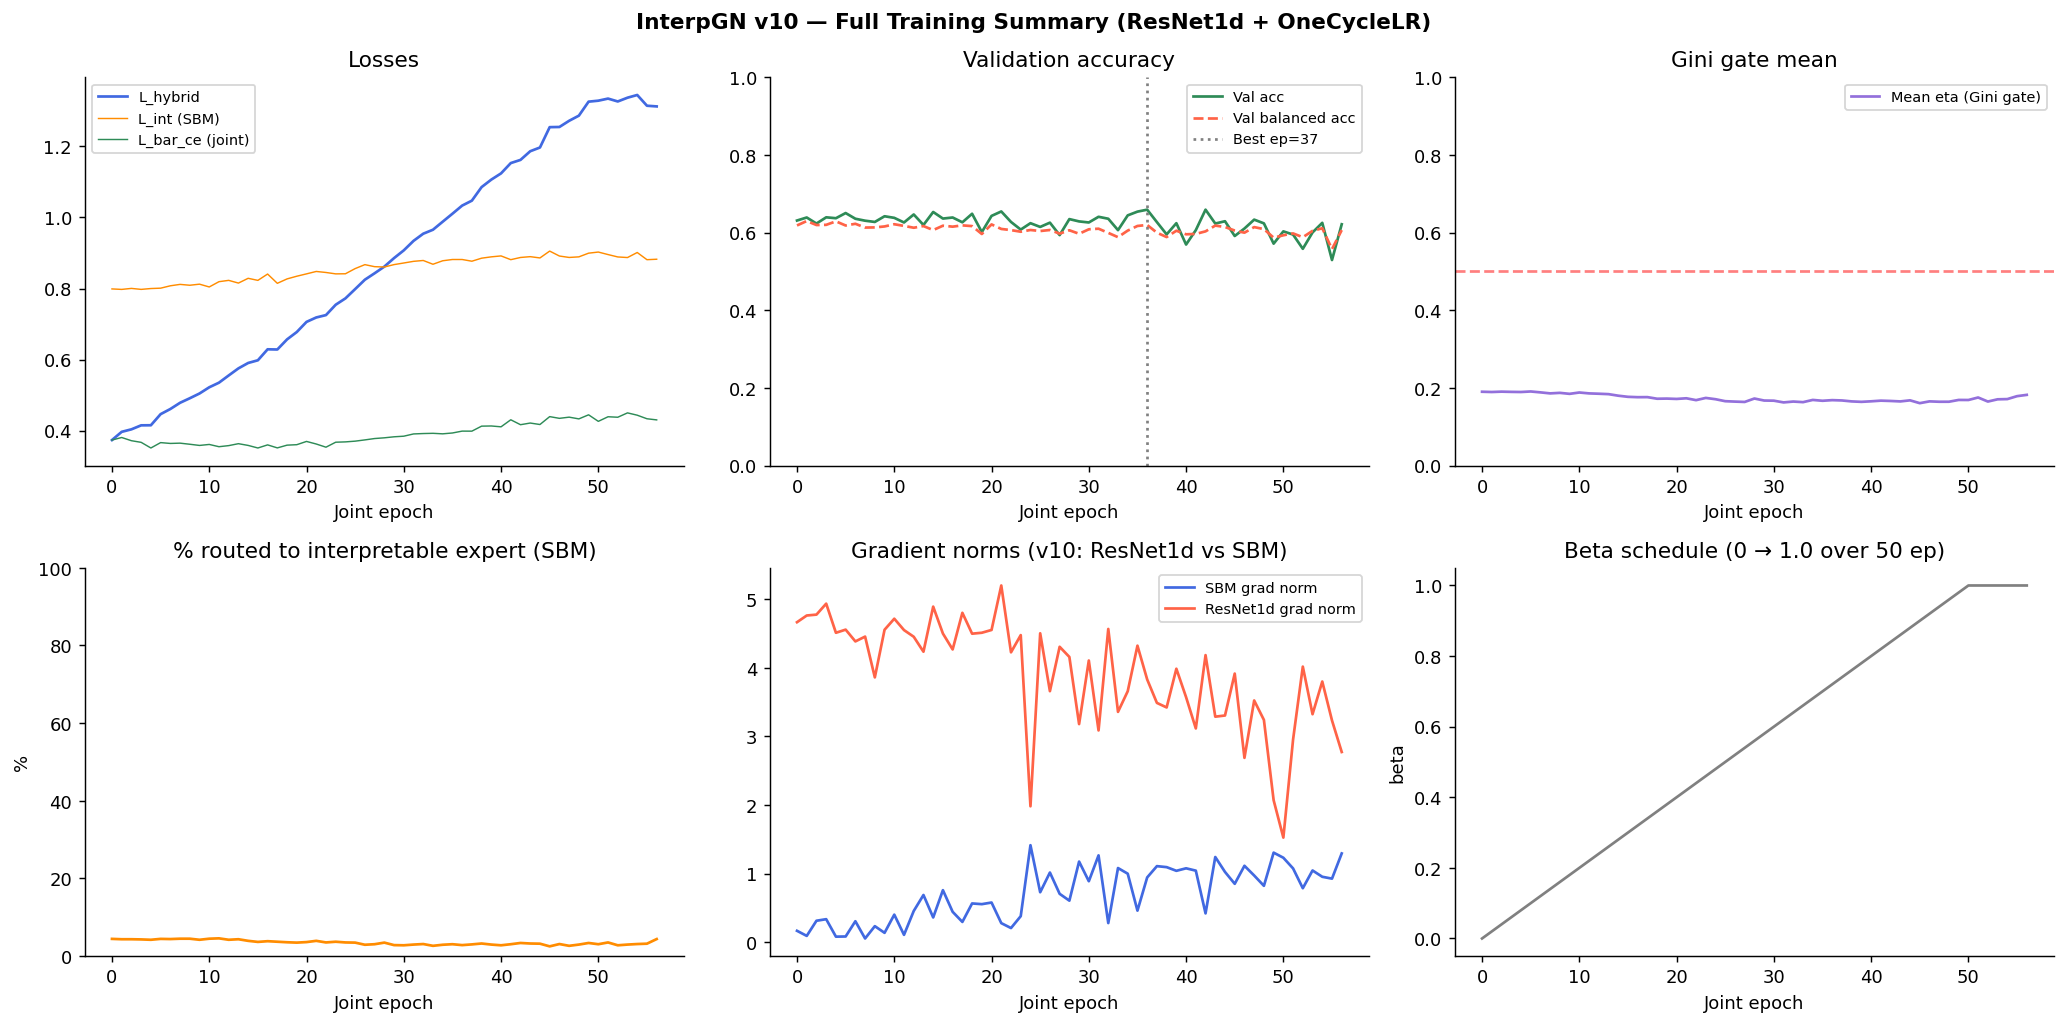

In [35]:
# Training curves
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

ax = axes[0,0]
ax.plot(history['train_loss'], color='royalblue', label='L_hybrid')
ax.plot(history['l_int'],      color='darkorange', lw=0.8, label='L_int (SBM)')
ax.plot(history['l_bar_ce'],   color='seagreen',   lw=0.8, label='L_bar_ce (joint)')
ax.set_title('Losses'); ax.legend(fontsize=8); ax.set_xlabel('Joint epoch')

ax = axes[0,1]
ax.plot(history['val_acc'],     color='seagreen',   label='Val acc')
ax.plot(history['val_bal_acc'], color='tomato', ls='--', label='Val balanced acc')
ax.axvline(es_joint.best_epoch, color='gray', ls=':', label=f'Best ep={es_joint.best_epoch+1}')
ax.set_ylim(0,1); ax.set_title('Validation accuracy')
ax.legend(fontsize=8); ax.set_xlabel('Joint epoch')

ax = axes[0,2]
ax.plot(history['gate_mean'], color='mediumpurple', label='Mean eta (Gini gate)')
ax.axhline(ETA_THRESHOLD, color='red', ls='--', alpha=0.5)
ax.set_ylim(0,1); ax.set_title('Gini gate mean')
ax.legend(fontsize=8); ax.set_xlabel('Joint epoch')

ax = axes[1,0]
ax.plot([r*100 for r in history['interp_rate']], color='darkorange')
ax.set_ylim(0,100); ax.set_title('% routed to interpretable expert (SBM)')
ax.set_xlabel('Joint epoch'); ax.set_ylabel('%')

ax = axes[1,1]
ax.plot(history['sbm_gnorm'], color='royalblue',  label='SBM grad norm')
ax.plot(history['res_gnorm'], color='tomato',     label='ResNet1d grad norm')
ax.set_title('Gradient norms (v10: ResNet1d vs SBM)')
ax.legend(fontsize=8); ax.set_xlabel('Joint epoch')

ax = axes[1,2]
ax.plot(history['beta'], color='gray')
ax.set_title(f'Beta schedule (0 → {BETA_MAX} over {BETA_RAMP_EP} ep)')
ax.set_xlabel('Joint epoch'); ax.set_ylabel('beta')

plt.suptitle('InterpGN v10 — Full Training Summary (ResNet1d + OneCycleLR)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/06_training_curves.png', bbox_inches='tight')
plt.show()


## Section 7 – Test Performance: How Good is Our Model?

**What we do:** Evaluate the trained model on TEST data it has never seen before.

We calculate:
- **Accuracy**: (# correct) / (# total) 
- **Balanced Accuracy**: Average per-class accuracy (important when classes are imbalanced!)
- **AUC-ROC**: Measures ability to distinguish between classes
- **ROC Curves**: Show the tradeoff between true positive rate and false positive rate
- **Confusion Matrix**: Show which classes are confused with which

In [36]:
model.eval()
test_acc, test_bal, y_pred, y_true = evaluate(model, test_dl)

all_probs, all_true = [], []
with torch.no_grad():
    for x, lbl in test_dl:
        out = model.forward_inference(x.to(DEVICE))
        all_probs.append(F.softmax(out['logits'],-1).cpu().numpy())
        all_true.append(lbl.numpy())
all_probs = np.concatenate(all_probs)
all_true  = np.concatenate(all_true)

y_oh = label_binarize(all_true, classes=list(range(N_CLASSES)))
try:
    macro_auc = roc_auc_score(y_oh, all_probs, multi_class='ovr', average='macro')
except Exception as e:
    macro_auc = float('nan'); print(e)

print('='*65)
print('InterpGN v10 — Test Results')
print('='*65)
print(f'  Test Accuracy          : {test_acc:.4f}')
print(f'  Balanced Test Accuracy : {test_bal:.4f}')
print(f'  Macro AUC (OvR)        : {macro_auc:.4f}')
print()
print('  PTB-XL Superdiagnostic Benchmark (Strodthoff 2020):')
print('    xresnet1d101                    : ~0.928 macro AUC')
print('    FCN-Wang (v9 backbone)          : ~0.925 macro AUC')
print(f'    InterpGN v10 (ResNet1d)         : {macro_auc:.4f} macro AUC + interpretability')
print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))


InterpGN v10 — Test Results
  Test Accuracy          : 0.6524
  Balanced Test Accuracy : 0.5989
  Macro AUC (OvR)        : 0.8649

  PTB-XL Superdiagnostic Benchmark (Strodthoff 2020):
    xresnet1d101                    : ~0.928 macro AUC
    FCN-Wang (v9 backbone)          : ~0.925 macro AUC
    InterpGN v10 (ResNet1d)         : 0.8649 macro AUC + interpretability

              precision    recall  f1-score   support

        NORM     0.8459    0.7163    0.7757       973
          MI     0.7031    0.5474    0.6156       411
        STTC     0.6016    0.6257    0.6134       350
          CD     0.5649    0.7066    0.6278       351
         HYP     0.1793    0.3982    0.2473       113

    accuracy                         0.6524      2198
   macro avg     0.5790    0.5989    0.5760      2198
weighted avg     0.7012    0.6524    0.6692      2198



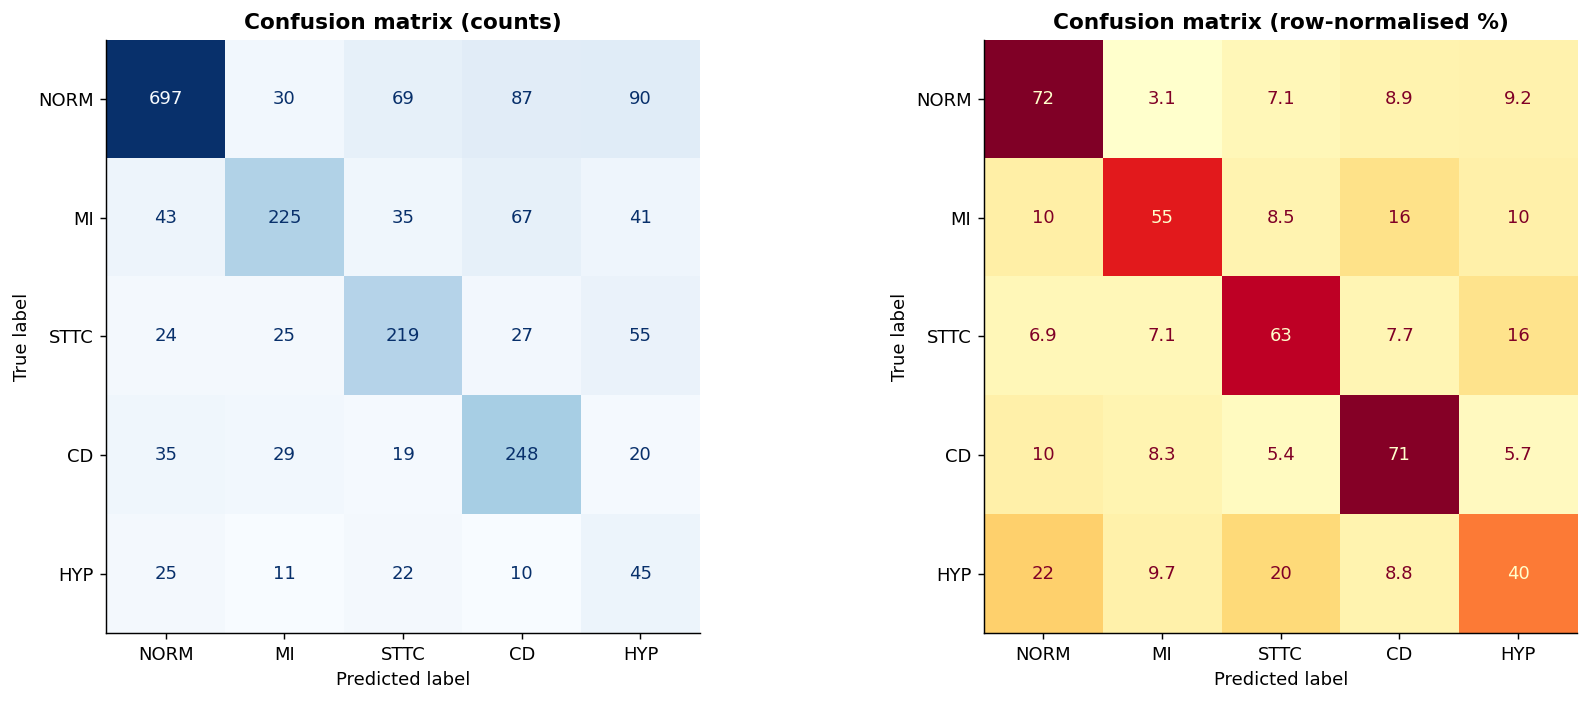

In [37]:
# Confusion matrix
cm     = confusion_matrix(y_true, y_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
ConfusionMatrixDisplay(cm,              display_labels=CLASS_NAMES).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix (counts)', fontweight='bold')
ConfusionMatrixDisplay(cm_pct.round(1), display_labels=CLASS_NAMES).plot(
    ax=axes[1], colorbar=False, cmap='YlOrRd')
axes[1].set_title('Confusion matrix (row-normalised %)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/07_confusion_matrix.png', bbox_inches='tight')
plt.show()


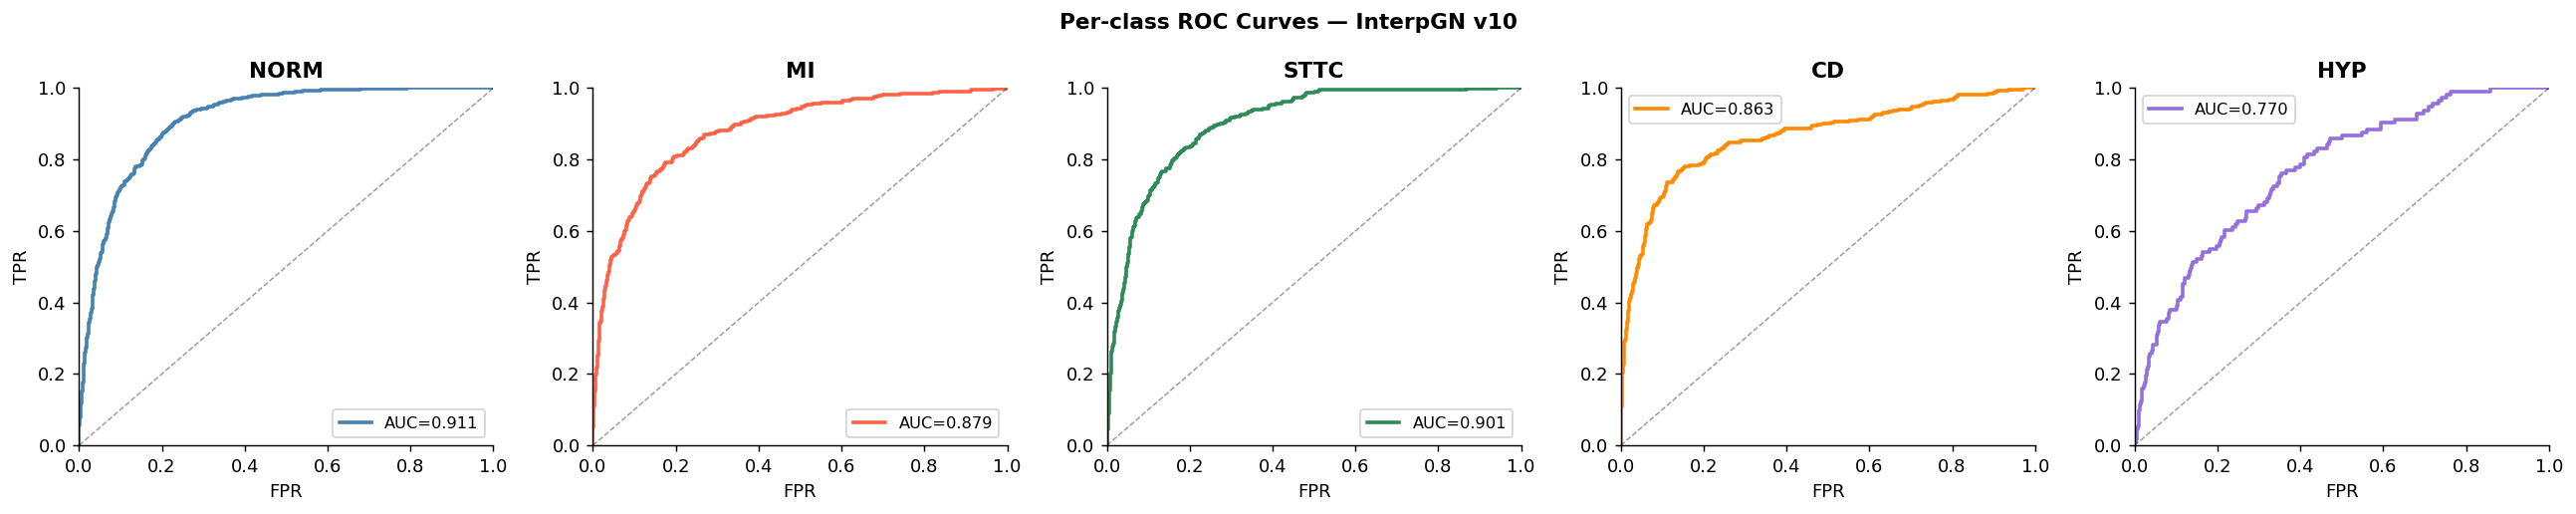

In [38]:
# ── Per-class ROC curves (NEW in v10) ─────────────────────────────────────────
fig, axes = plt.subplots(1, N_CLASSES, figsize=(4*N_CLASSES, 4))
for i, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    fpr, tpr, _ = roc_curve(y_oh[:, i], all_probs[:, i])
    auc_i = roc_auc_score(y_oh[:, i], all_probs[:, i])
    axes[i].plot(fpr, tpr, color=color, lw=2, label=f'AUC={auc_i:.3f}')
    axes[i].plot([0,1],[0,1],'k--', lw=0.8, alpha=0.4)
    axes[i].set_xlim(0,1); axes[i].set_ylim(0,1)
    axes[i].set_xlabel('FPR'); axes[i].set_ylabel('TPR')
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].legend(fontsize=9)
plt.suptitle('Per-class ROC Curves — InterpGN v10', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/07_roc_curves.png', bbox_inches='tight')
plt.show()


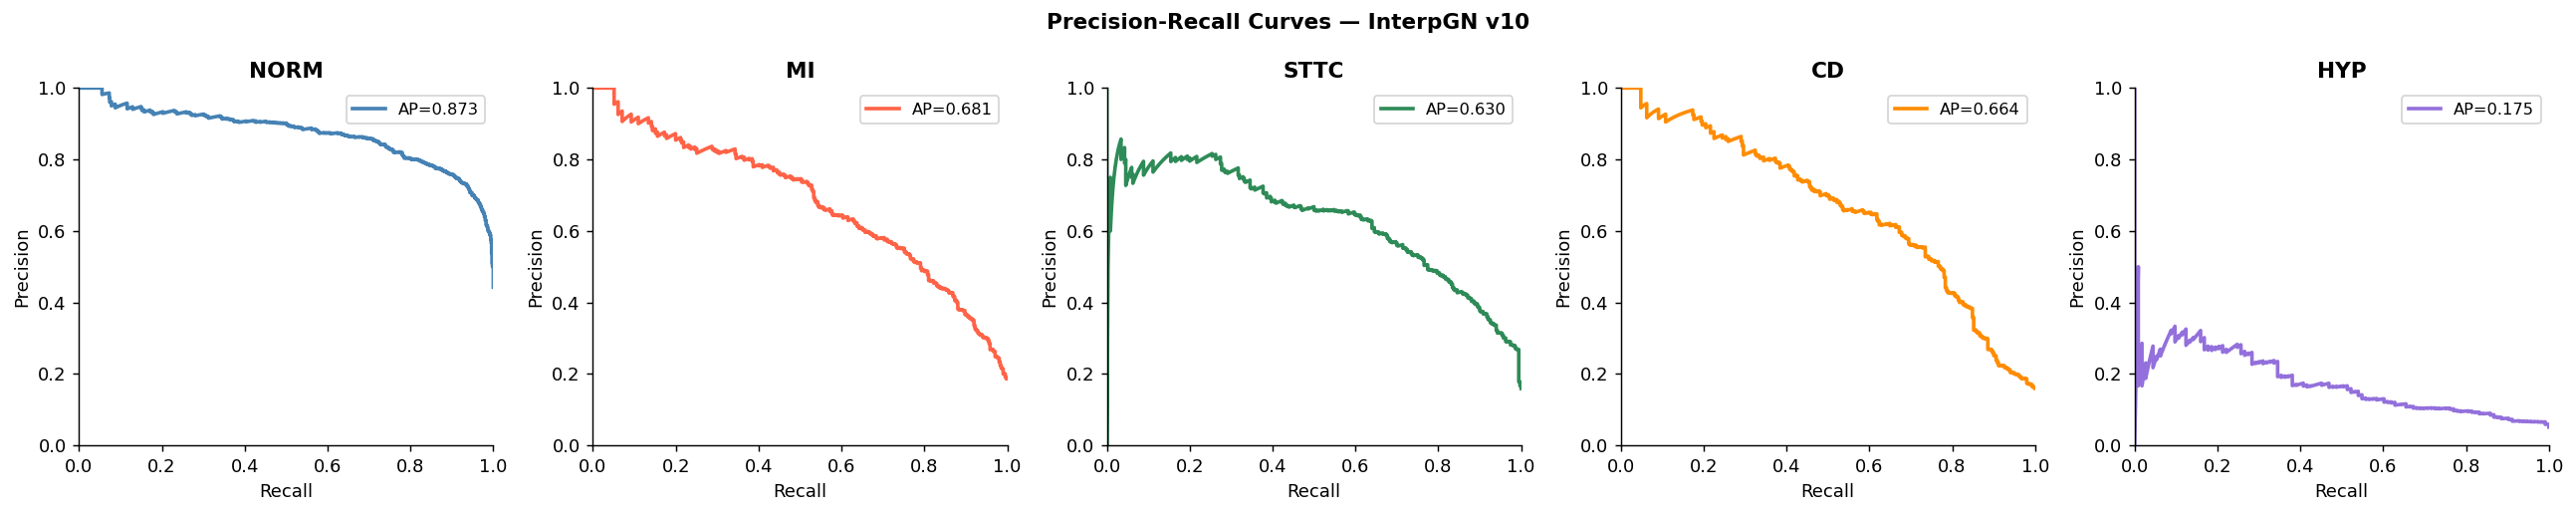

In [39]:
# ── Precision-Recall curves (NEW in v10) ──────────────────────────────────────
fig, axes = plt.subplots(1, N_CLASSES, figsize=(4*N_CLASSES, 4))
for i, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    prec, rec, _ = precision_recall_curve(y_oh[:, i], all_probs[:, i])
    ap = average_precision_score(y_oh[:, i], all_probs[:, i])
    axes[i].plot(rec, prec, color=color, lw=2, label=f'AP={ap:.3f}')
    axes[i].set_xlim(0,1); axes[i].set_ylim(0,1)
    axes[i].set_xlabel('Recall'); axes[i].set_ylabel('Precision')
    axes[i].set_title(f'{name}', fontweight='bold')
    axes[i].legend(fontsize=9)
plt.suptitle('Precision-Recall Curves — InterpGN v10', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/07_pr_curves.png', bbox_inches='tight')
plt.show()


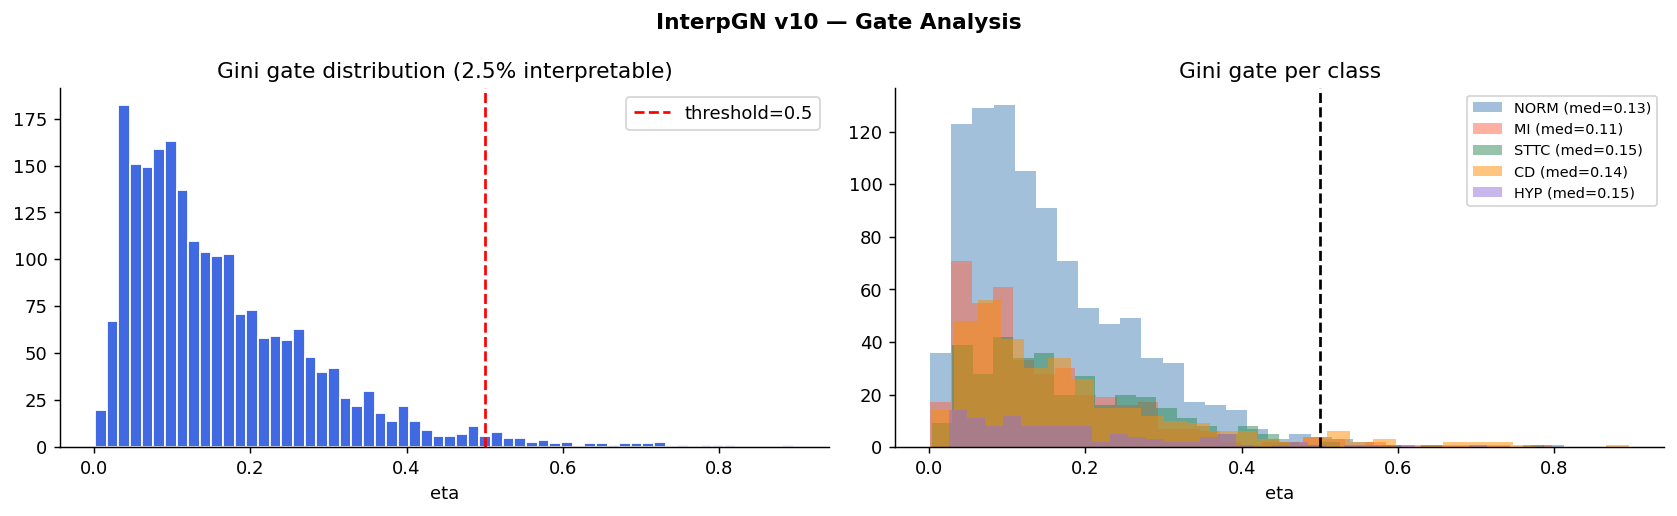

Per-class routing:
  NORM    1.0% interpretable  mean_eta=0.154
  MI      3.4% interpretable  mean_eta=0.153
  STTC    1.4% interpretable  mean_eta=0.179
  CD      6.0% interpretable  mean_eta=0.183
  HYP     4.4% interpretable  mean_eta=0.188


In [40]:
g_test, y_test_g = get_gate_stats(model, test_dl)
pct_interp       = (g_test > ETA_THRESHOLD).mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(g_test, bins=60, color='royalblue', edgecolor='white')
axes[0].axvline(ETA_THRESHOLD, color='red', ls='--',
                label=f'threshold={ETA_THRESHOLD}')
axes[0].set_title(f'Gini gate distribution ({pct_interp:.1f}% interpretable)')
axes[0].set_xlabel('eta'); axes[0].legend()

for i, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    vals = g_test[y_test_g == i]
    axes[1].hist(vals, bins=30, alpha=0.5, color=color,
                 label=f'{name} (med={np.median(vals):.2f})')
axes[1].axvline(ETA_THRESHOLD, color='black', ls='--')
axes[1].set_title('Gini gate per class'); axes[1].set_xlabel('eta')
axes[1].legend(fontsize=8)

plt.suptitle('InterpGN v10 — Gate Analysis', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/07_gate_analysis.png', bbox_inches='tight')
plt.show()

print('Per-class routing:')
for i, name in enumerate(CLASS_NAMES):
    vals = g_test[y_test_g == i]
    print(f'  {name:4s}  {(vals>ETA_THRESHOLD).mean()*100:5.1f}% interpretable  '
          f'mean_eta={vals.mean():.3f}')


## Section 8a – SBM Interpretability (Shapelet Gallery + Heatmaps + Instance Explanations)

Identical logic to v9 — shapelet gallery, classifier weight heatmap, predicate heatmap.


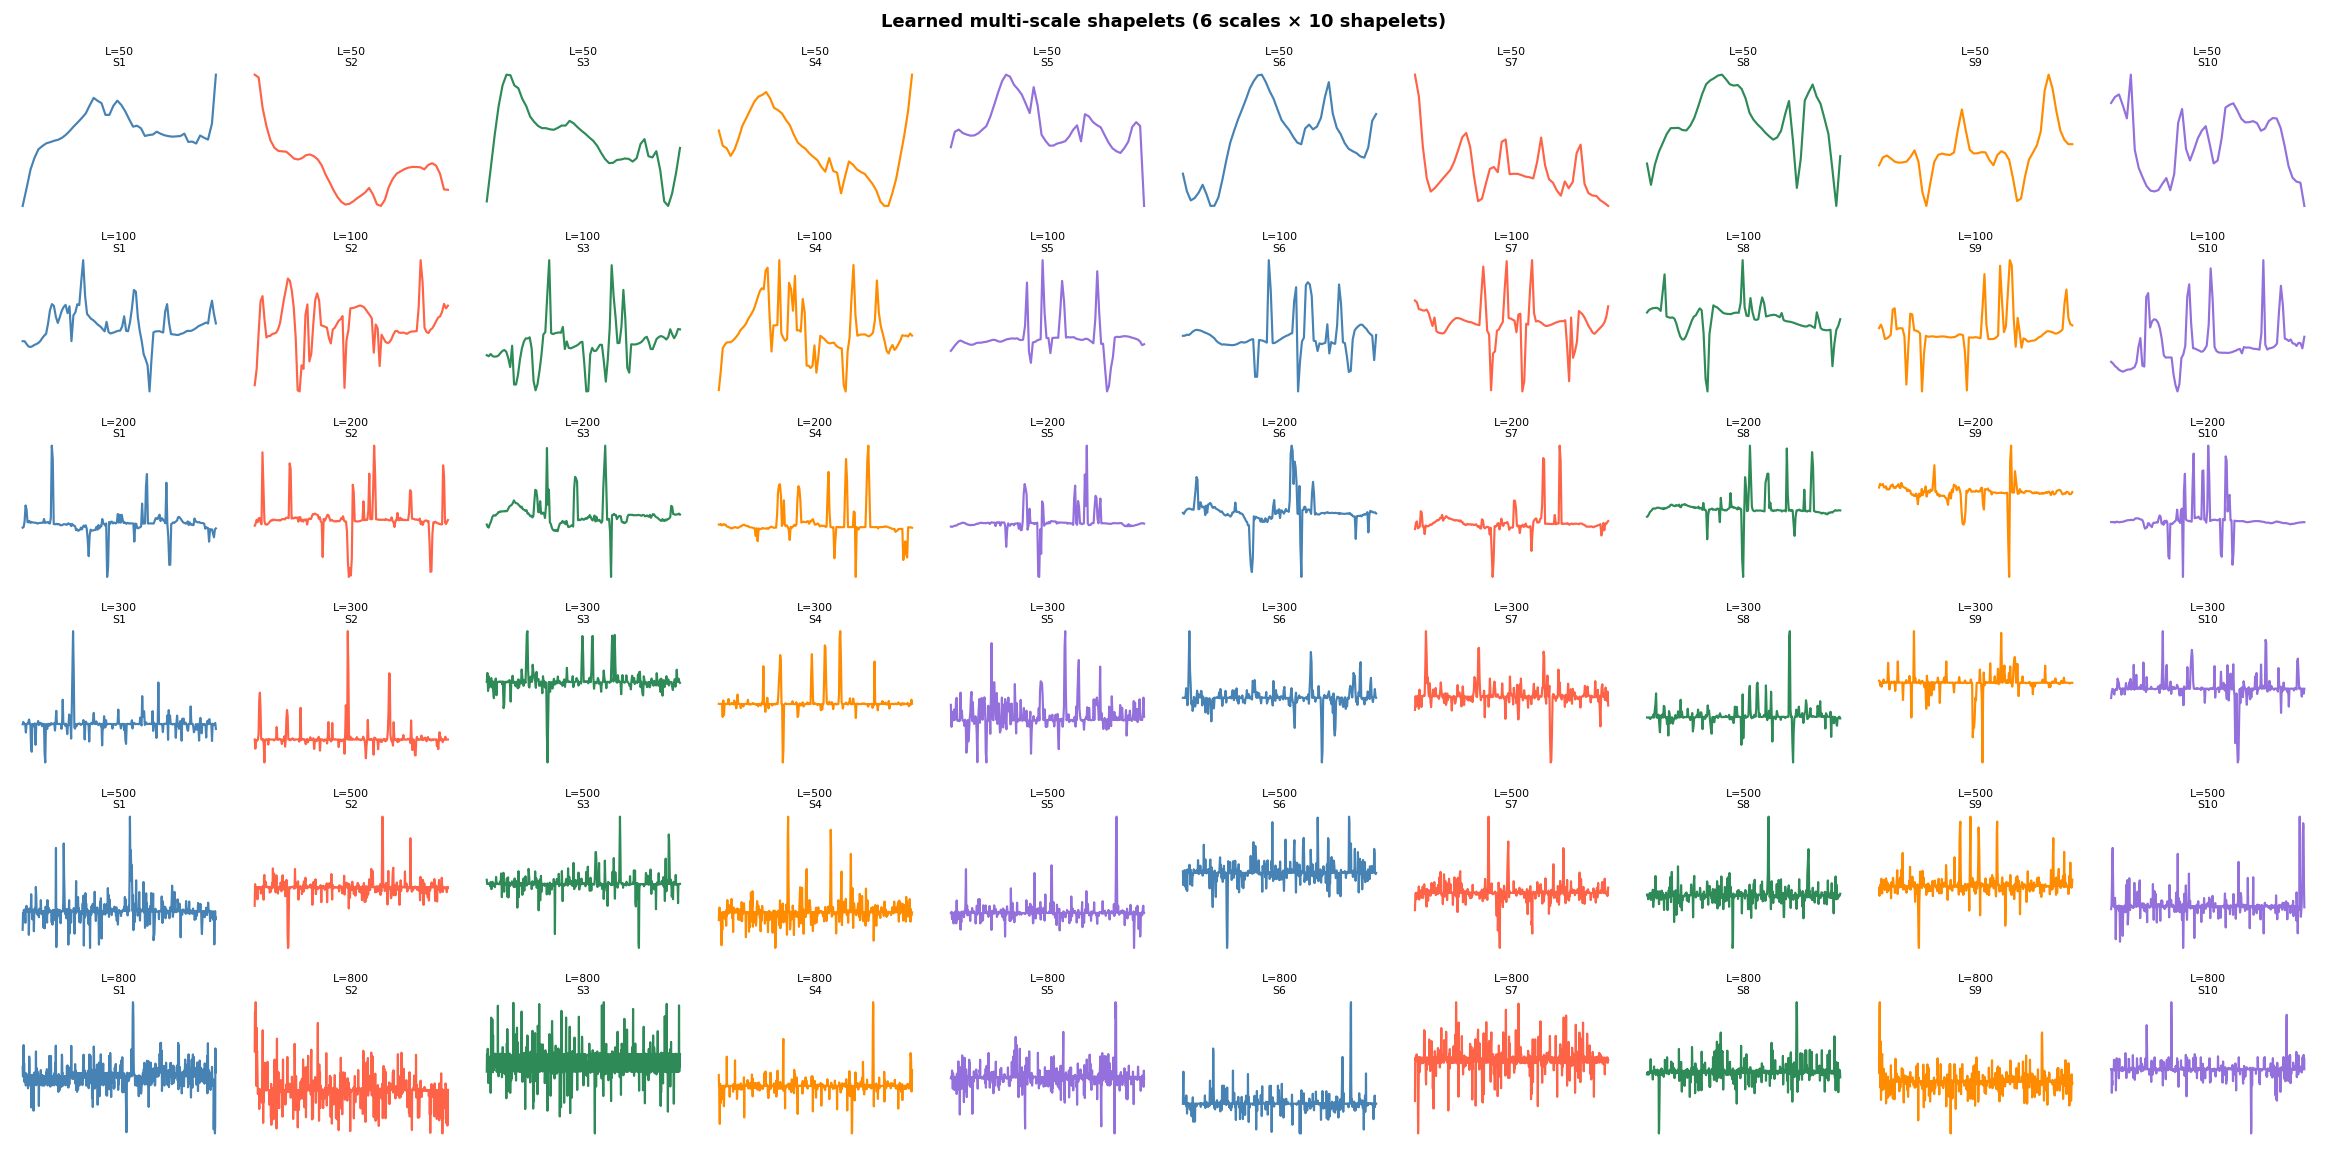

In [41]:
# Shapelet gallery
fig, axes = plt.subplots(len(SHAPELET_LENS), K_SHAPELETS,
                         figsize=(K_SHAPELETS*1.8, len(SHAPELET_LENS)*1.5),
                         squeeze=False)
for si, (layer, L) in enumerate(zip(model.sbm.shapelet_layers, SHAPELET_LENS)):
    s_avg = layer.shapelet.detach().cpu().numpy().mean(0)   # (K, L)
    for ki in range(K_SHAPELETS):
        ax = axes[si][ki]
        ax.plot(s_avg[ki], lw=1.2, color=CLASS_COLORS[ki % len(CLASS_COLORS)])
        ax.set_title(f'L={L}\nS{ki+1}', fontsize=6, pad=1)
        ax.axis('off')
    axes[si][0].set_ylabel(f'Scale {si+1}\n(L={L})', fontsize=7, rotation=0, labelpad=36)

plt.suptitle(f'Learned multi-scale shapelets ({len(SHAPELET_LENS)} scales × {K_SHAPELETS} shapelets)',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/08a_shapelet_gallery.png', bbox_inches='tight', dpi=90)
plt.show()


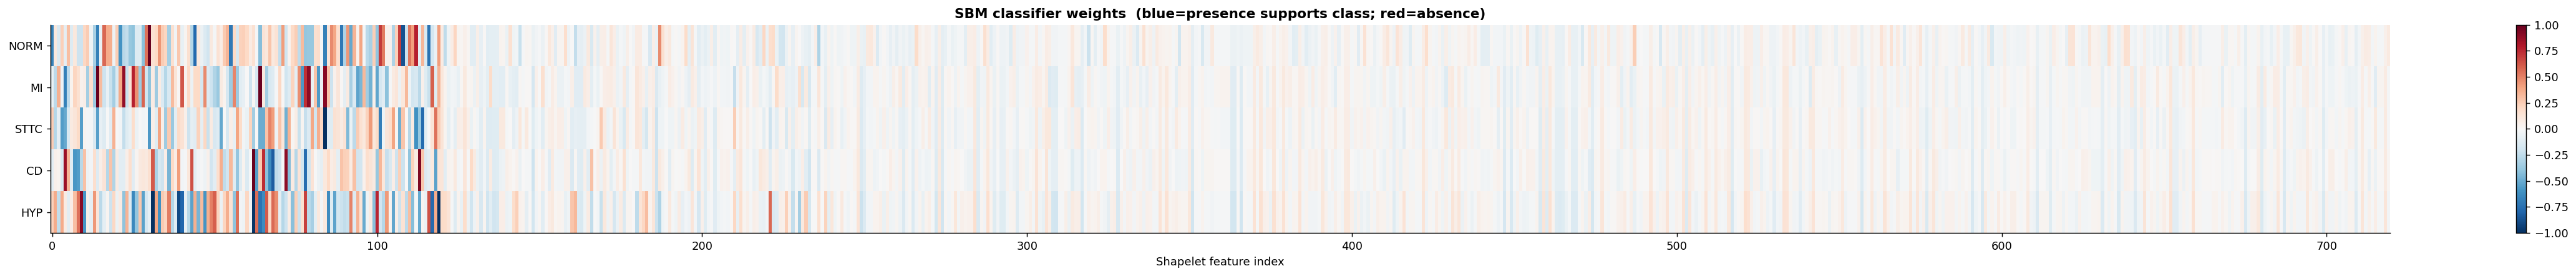

Top-5 positive features per class:
  NORM: feats=[30, 112, 101, 107, 16]  w=[1.468 1.144 1.024 1.012 0.845]
  MI  : feats=[14, 64, 84, 79, 22]  w=[2.001 1.984 1.822 1.798 1.755]
  STTC: feats=[118, 67, 98, 68, 33]  w=[1.121 1.024 0.876 0.863 0.831]
  CD  : feats=[62, 113, 72, 4, 65]  w=[2.203 2.062 1.967 1.878 1.623]
  HYP : feats=[9, 100, 78, 116, 66]  w=[1.488 1.245 1.121 1.04  1.011]


In [42]:
# Classifier weight heatmap
with torch.no_grad():
    W = model.sbm.classifier.weight.cpu().numpy()   # (N_CLASSES, n_feats)
W_norm = W / (np.abs(W).max(axis=1, keepdims=True) + 1e-8)

fig, ax = plt.subplots(figsize=(min(W.shape[1]//5, 32), 3.5))
im = ax.imshow(W_norm, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_yticks(range(N_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel('Shapelet feature index')
ax.set_title('SBM classifier weights  (blue=presence supports class; red=absence)',
             fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/08a_importance_heatmap.png', bbox_inches='tight', dpi=110)
plt.show()

print('Top-5 positive features per class:')
for i, name in enumerate(CLASS_NAMES):
    top5 = np.argsort(W[i])[::-1][:5]
    print(f'  {name:4s}: feats={list(top5)}  w={W[i][top5].round(3)}')


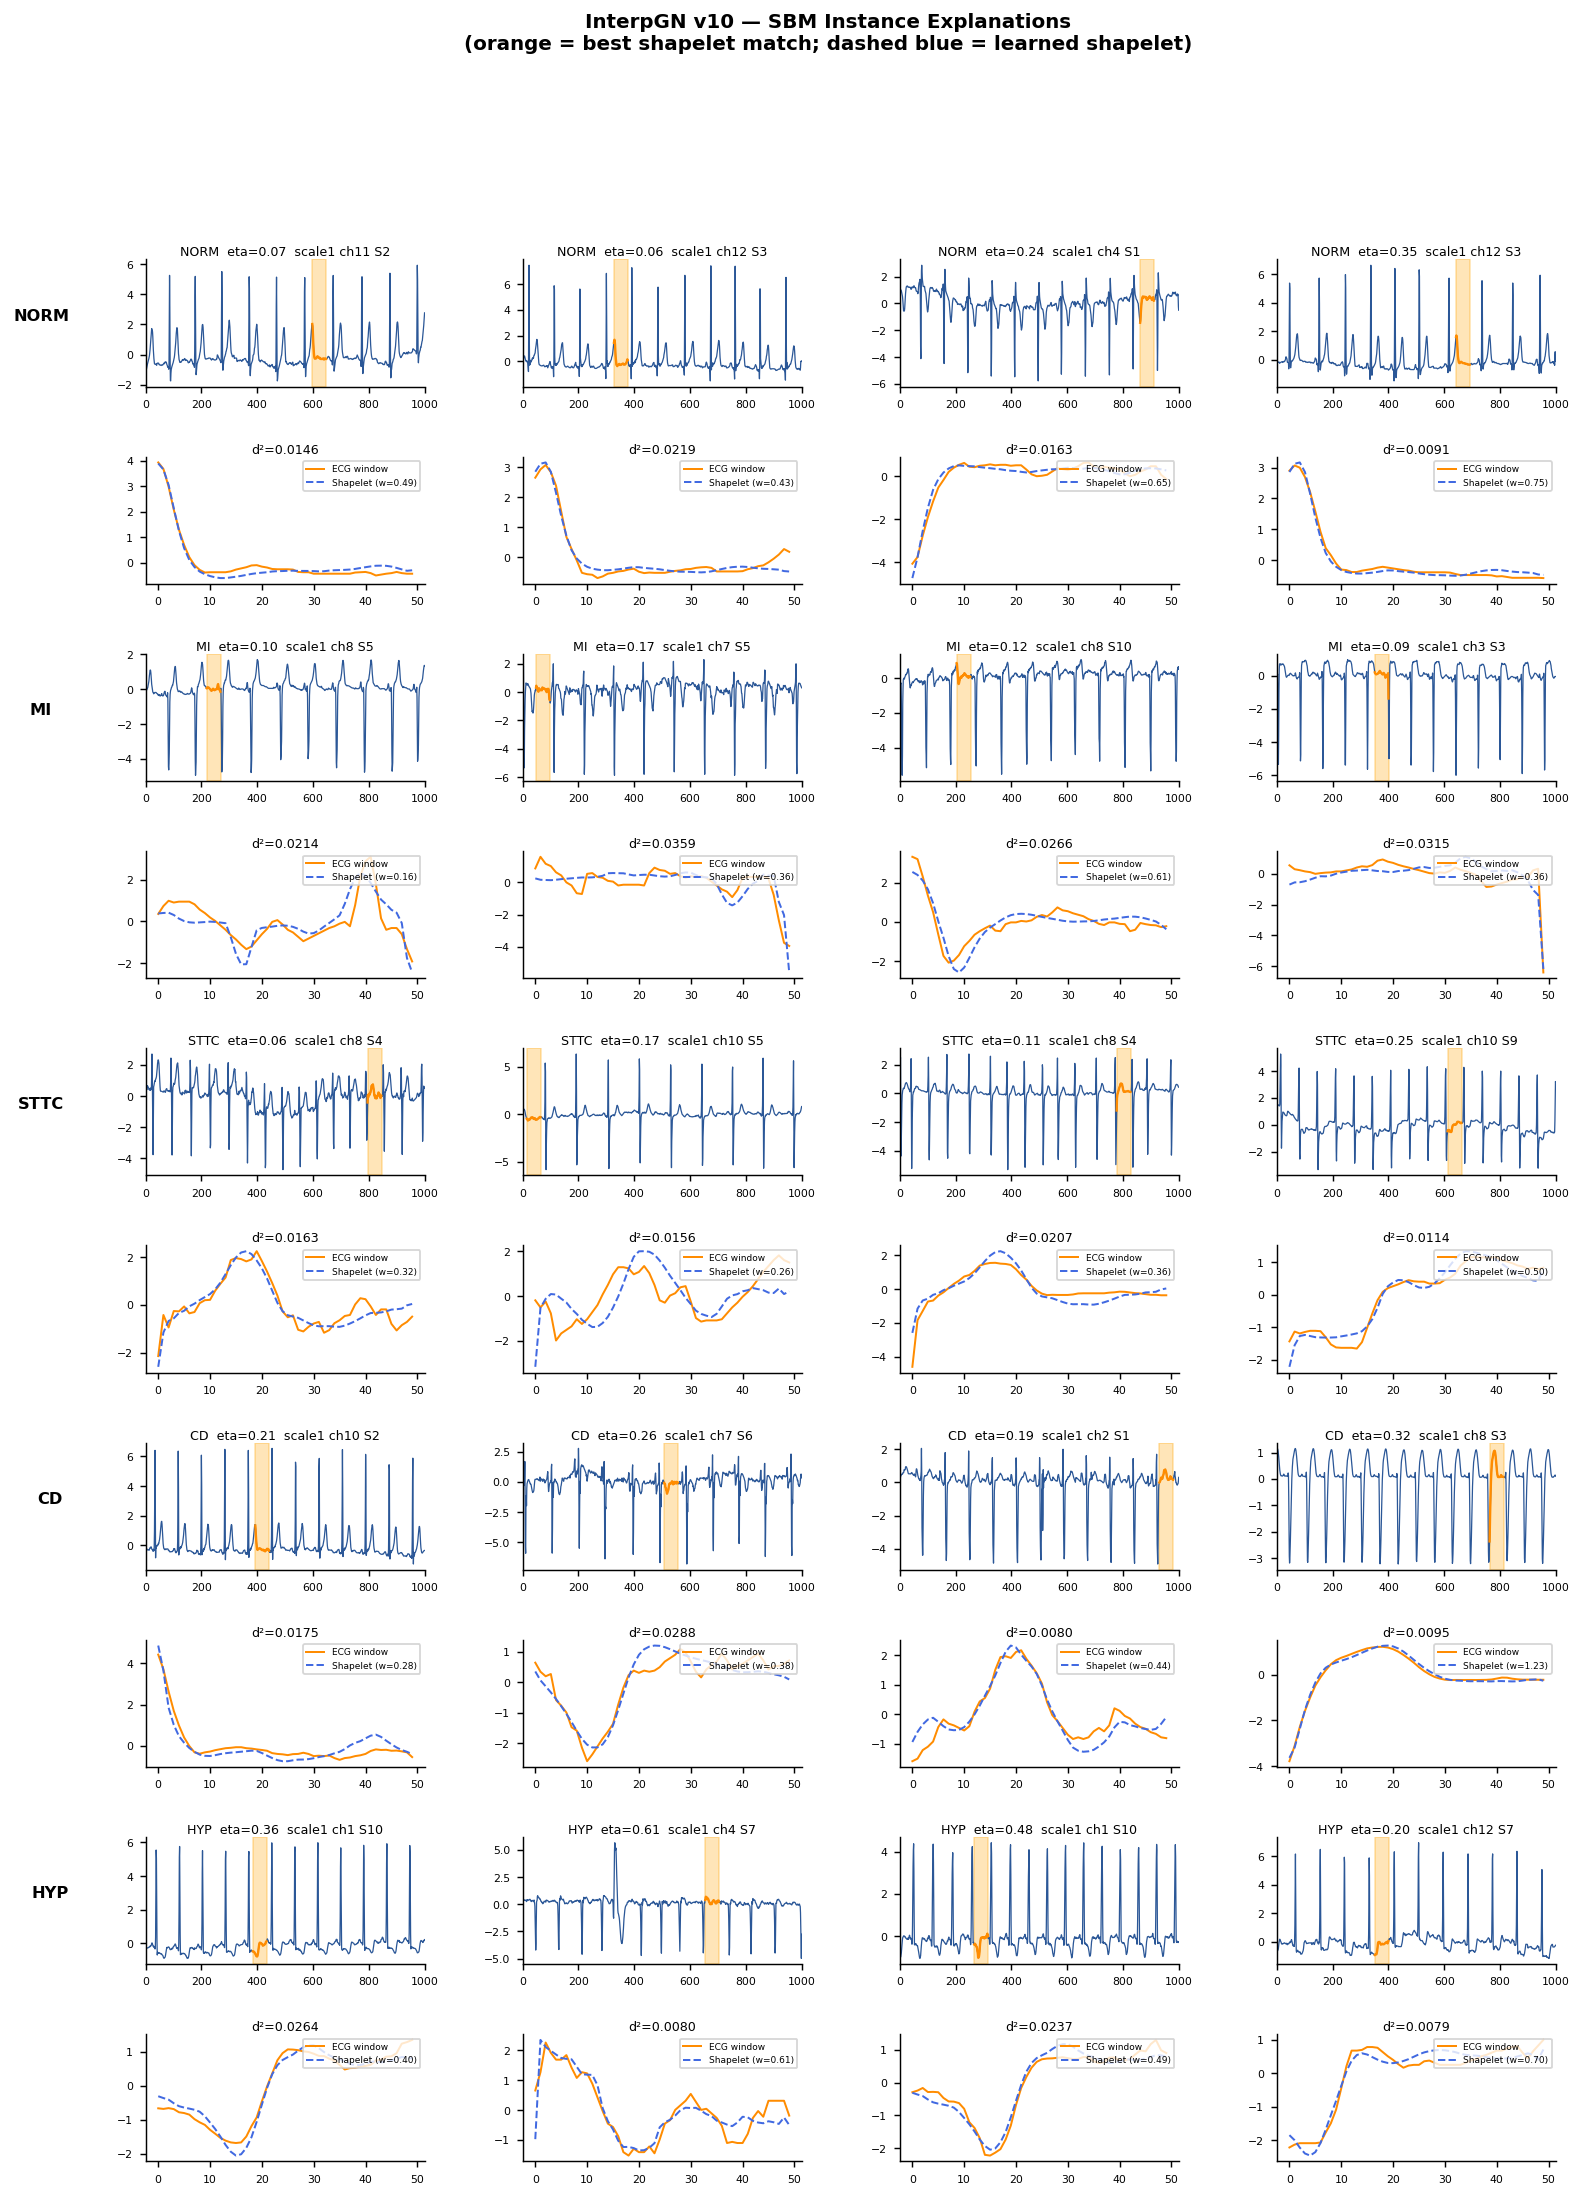

In [43]:
# Instance explanation helper
def get_best_feature(predicates_vec, W, class_label):
    contrib   = W[class_label] * predicates_vec
    best_feat = int(np.argmax(contrib))
    fps       = N_CHANNELS * K_SHAPELETS
    scale_idx = best_feat // fps
    rem       = best_feat %  fps
    ch        = rem // K_SHAPELETS
    k_idx     = rem %  K_SHAPELETS
    return scale_idx, ch, k_idx, contrib[best_feat]


def plot_explanation(ax_sig, ax_shap, sample, W, shap_layers):
    x_raw = sample['x_raw']
    c     = sample['label']
    preds = sample['predicates']
    gate  = sample['gate']

    si, ch, ki, contrib = get_best_feature(preds, W, c)
    shapelet_np = shap_layers[si].shapelet[ch, ki].detach().cpu().numpy()
    L     = len(shapelet_np)
    stride = max(1, int(math.log(max(L, 2))))

    sig  = x_raw[ch]
    wins = np.lib.stride_tricks.sliding_window_view(sig, L)[::stride]
    d2   = ((wins - shapelet_np)**2).mean(axis=1)
    bw   = int(np.argmin(d2)); start = bw * stride

    ax_sig.plot(sig, color='#2b5797', lw=0.7)
    ax_sig.axvspan(start, start+L, color='orange', alpha=0.28)
    ax_sig.plot(np.arange(start, start+L), sig[start:start+L],
                color='darkorange', lw=1.3)
    ax_sig.set_title(f'{CLASS_NAMES[c]}  eta={gate:.2f}  '
                     f'scale{si+1} ch{ch+1} S{ki+1}', fontsize=7, pad=2)
    ax_sig.set_xlim(0, len(sig)); ax_sig.tick_params(labelsize=6)

    win_seg = sig[start:start+L]
    wn = (win_seg - win_seg.mean()) / (win_seg.std()+1e-6)
    sn = (shapelet_np - shapelet_np.mean()) / (shapelet_np.std()+1e-6)
    ax_shap.plot(wn, color='darkorange', lw=1.1, label='ECG window')
    ax_shap.plot(sn, color='royalblue',  lw=1.1, ls='--',
                 label=f'Shapelet (w={contrib:.2f})')
    ax_shap.set_title(f'd²={d2[bw]:.4f}', fontsize=7, pad=2)
    ax_shap.legend(fontsize=5, loc='upper right')
    ax_shap.tick_params(labelsize=6)


# Collect examples
N_EXPLAIN = 4
model.eval()
explained = {c: [] for c in range(N_CLASSES)}
with torch.no_grad():
    for x, lbl in test_dl:
        out   = model.forward_inference(x.to(DEVICE))
        preds = out['logits'].argmax(-1).cpu()
        eta   = out['gate'].cpu().numpy()
        for i in range(len(lbl)):
            c = lbl[i].item()
            if preds[i].item() == c and len(explained[c]) < N_EXPLAIN:
                explained[c].append({
                    'x_raw'     : x[i].cpu().numpy(),
                    'gate'      : float(eta[i]),
                    'predicates': out['predicates'][i].cpu().numpy(),
                    'label'     : c,
                })
        if all(len(v) >= N_EXPLAIN for v in explained.values()):
            break

shap_layers = list(model.sbm.shapelet_layers)
fig, axes = plt.subplots(N_CLASSES*2, N_EXPLAIN,
                          figsize=(N_EXPLAIN*3.5, N_CLASSES*2*1.9),
                          gridspec_kw={'hspace':0.55, 'wspace':0.35})

for ci in range(N_CLASSES):
    for si, samp in enumerate(explained[ci]):
        plot_explanation(axes[ci*2][si], axes[ci*2+1][si], samp, W, shap_layers)
    axes[ci*2][0].set_ylabel(CLASS_NAMES[ci], fontsize=9, fontweight='bold',
                              rotation=0, labelpad=42)

plt.suptitle('InterpGN v10 — SBM Instance Explanations\n'
             '(orange = best shapelet match; dashed blue = learned shapelet)',
             fontsize=11, fontweight='bold')
plt.savefig(f'{OUTPUTS_DIR}/08a_instance_explanations.png',
            bbox_inches='tight', dpi=110)
plt.show()


## Section 8b – Grad-CAM Saliency Maps on ResNet1d (NEW in v10)

Grad-CAM computes a **temporal saliency map** over the ECG signal:  
- Hook the last conv block (`layer3`) of ResNet1d  
- Backprop w.r.t. the predicted class score  
- Weight feature-map channels by their globally-averaged gradients  
- Upsample to original signal length  

Result: a heatmap showing **which time segments** drove the ResNet1d decision,  
coloured per ECG lead.


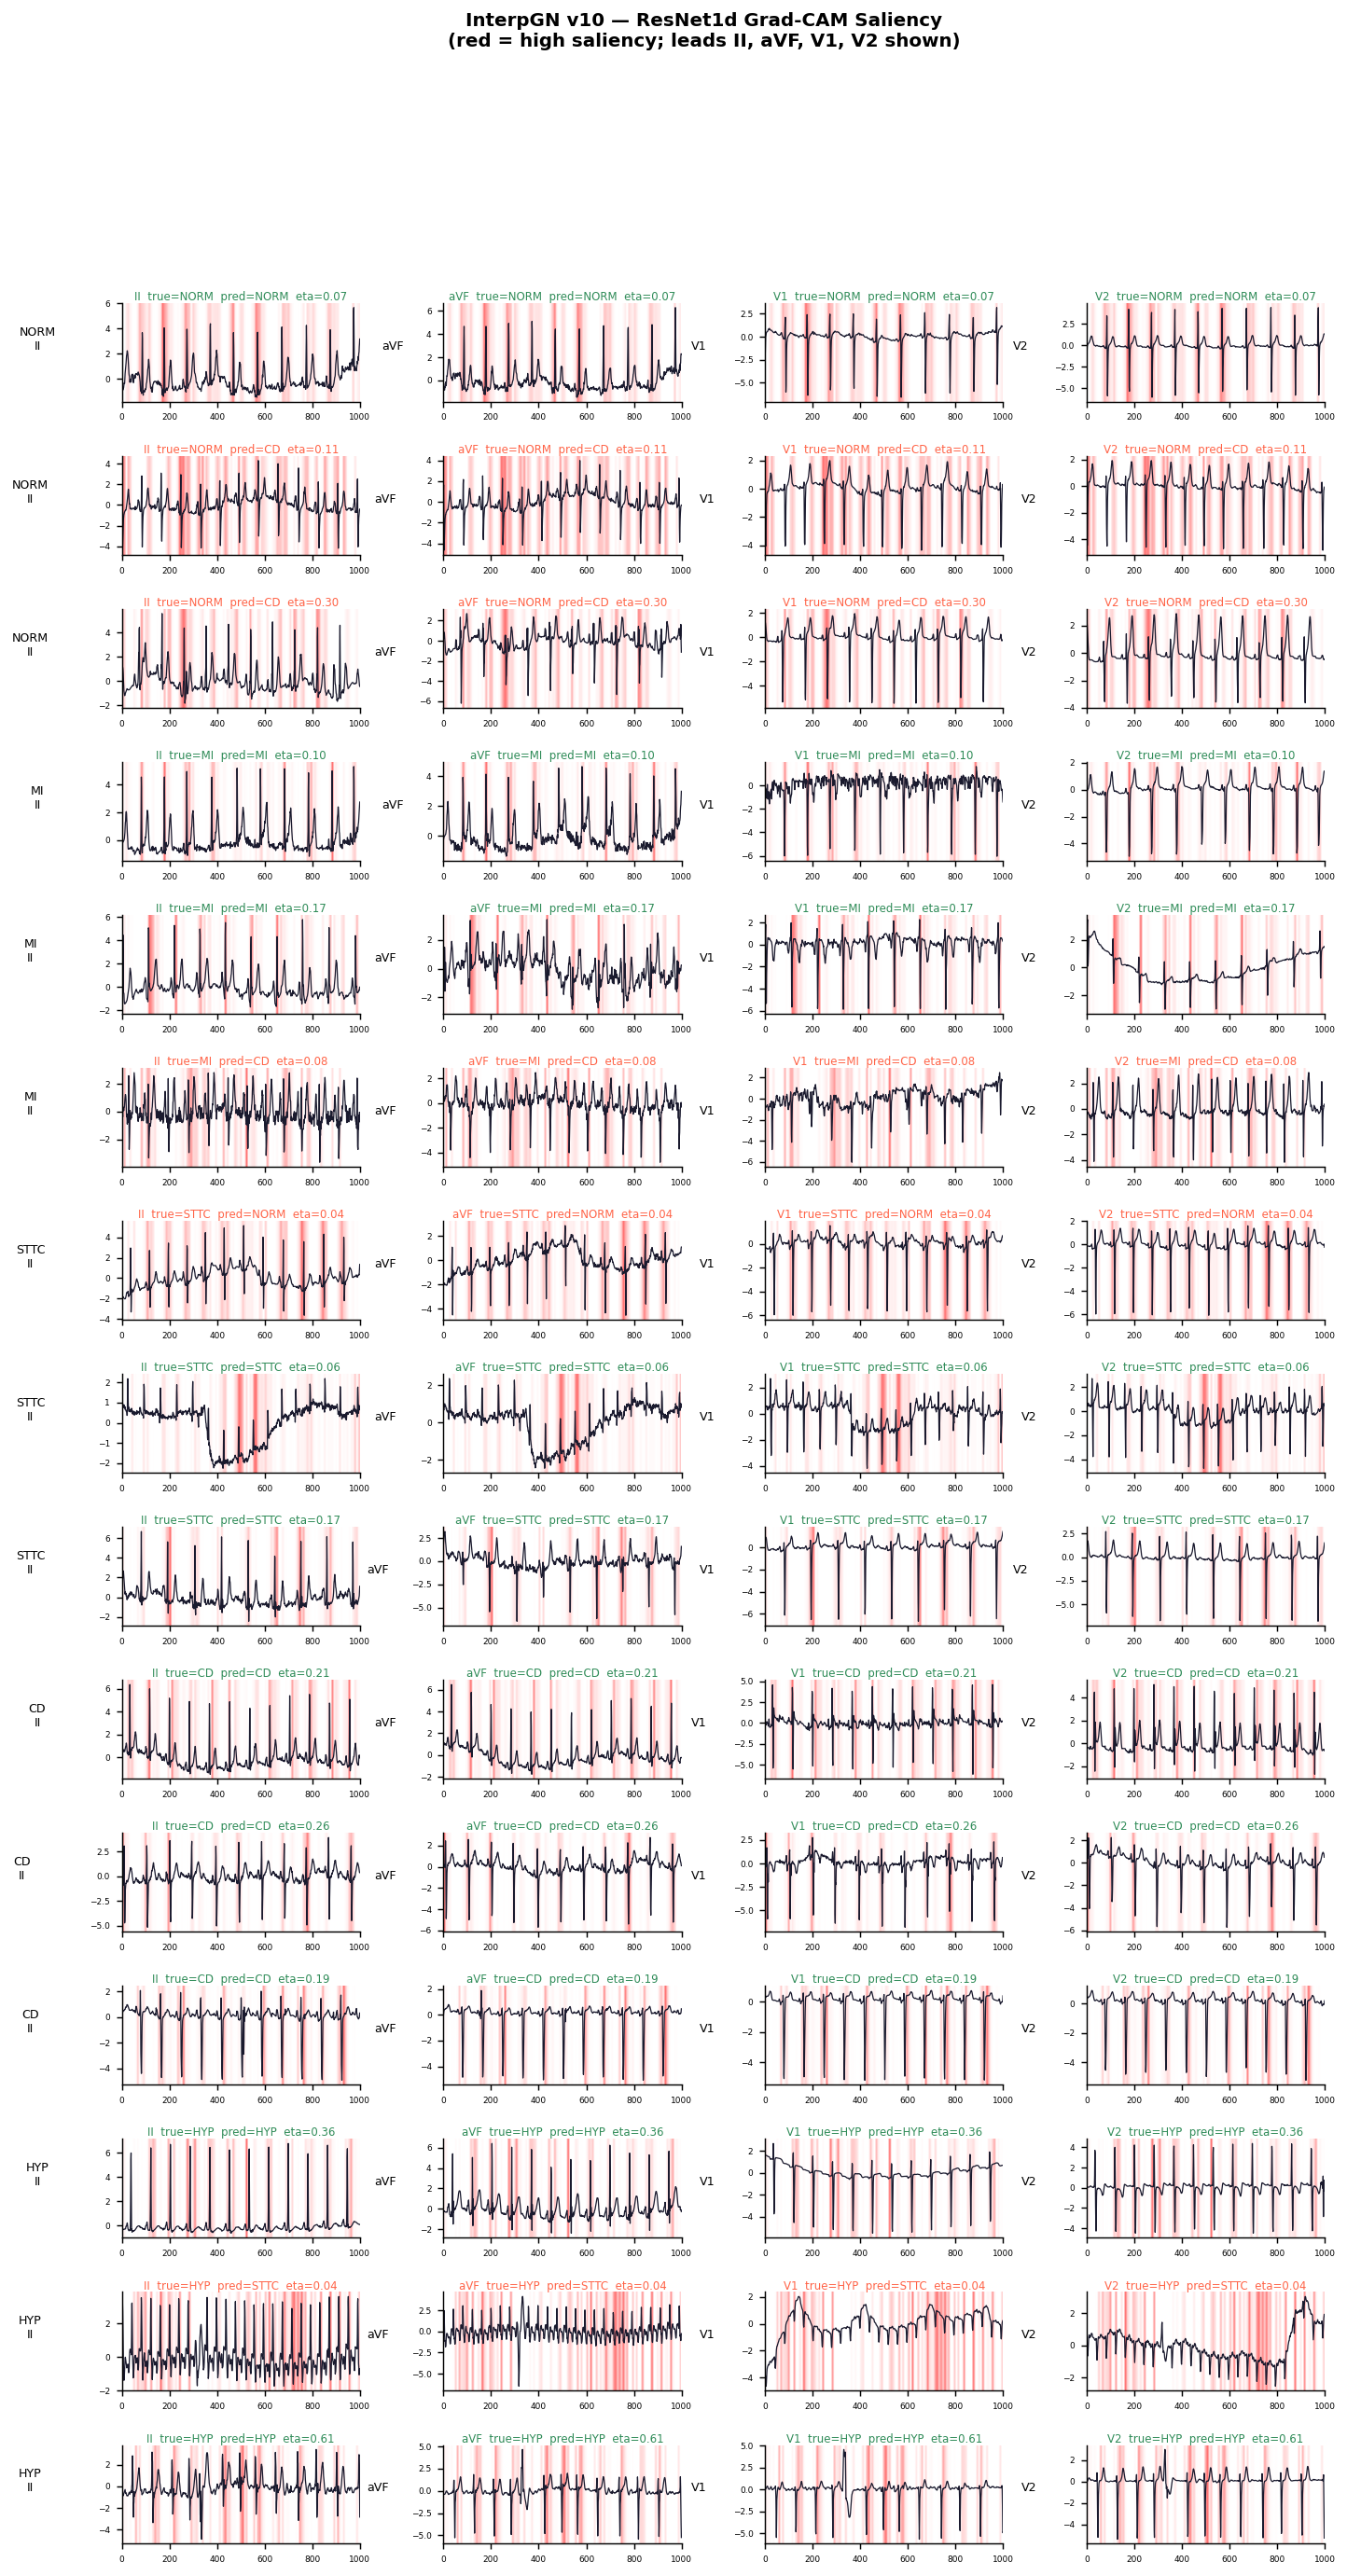

Grad-CAM plots saved.


In [44]:
# ── Grad-CAM visualisation — ResNet1d deep expert ──────────────────────────────
LEAD_NAMES = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

def plot_gradcam(axes_row, x_np, cam_np, label, pred, gate_val,
                 leads_to_show=(1, 5, 6, 7)):  # II, aVF, V1, V2 (clinical relevance)
    """
    Plot Grad-CAM overlay for selected leads.
    x_np  : (12, T)  signal
    cam_np: (T,)     saliency map
    """
    t = np.arange(x_np.shape[1])
    vmin, vmax = cam_np.min(), cam_np.max()
    for ax_idx, lead in enumerate(leads_to_show):
        ax = axes_row[ax_idx]
        sig = x_np[lead]
        # Heat-coloured background
        for j in range(len(t)-1):
            intensity = (cam_np[j] - vmin) / (vmax - vmin + 1e-8)
            ax.axvspan(t[j], t[j+1], alpha=float(intensity)*0.55,
                       color='red', linewidth=0)
        ax.plot(t, sig, color='#1a1a2e', lw=0.7)
        title_col = 'seagreen' if label == pred else 'tomato'
        ax.set_title(f'{LEAD_NAMES[lead]}  true={CLASS_NAMES[label]}'
                     f'  pred={CLASS_NAMES[pred]}'
                     f'  eta={gate_val:.2f}',
                     fontsize=6.5, pad=1.5, color=title_col)
        ax.set_xlim(0, len(t)); ax.tick_params(labelsize=5)
        ax.set_ylabel(LEAD_NAMES[lead], fontsize=7, rotation=0, labelpad=20)


N_GRADCAM = 3   # samples per class
gradcam_samples = {c: [] for c in range(N_CLASSES)}
model.eval()
with torch.no_grad():
    for x, lbl in test_dl:
        out   = model.forward_inference(x.to(DEVICE))
        preds = out['logits'].argmax(-1).cpu()
        eta   = out['gate'].cpu().numpy()
        for i in range(len(lbl)):
            c = lbl[i].item()
            if len(gradcam_samples[c]) < N_GRADCAM:
                gradcam_samples[c].append({
                    'x'    : x[i].cpu().numpy(),
                    'label': c,
                    'pred' : preds[i].item(),
                    'gate' : float(eta[i]),
                })
        if all(len(v) >= N_GRADCAM for v in gradcam_samples.values()):
            break

N_LEADS_SHOWN = 4
fig, axes = plt.subplots(
    N_CLASSES * N_GRADCAM, N_LEADS_SHOWN,
    figsize=(N_LEADS_SHOWN * 3.2, N_CLASSES * N_GRADCAM * 1.6),
    gridspec_kw={'hspace': 0.55, 'wspace': 0.35})

row = 0
for ci in range(N_CLASSES):
    for samp in gradcam_samples[ci]:
        x_t  = torch.from_numpy(samp['x']).unsqueeze(0).to(DEVICE)
        cam  = model.resnet.grad_cam(x_t, class_idx=torch.tensor([samp['label']]))
        cam_np = cam[0].numpy()
        plot_gradcam(axes[row], samp['x'], cam_np,
                     samp['label'], samp['pred'], samp['gate'])
        axes[row][0].set_ylabel(
            f'{CLASS_NAMES[ci]}\n{LEAD_NAMES[1]}',
            fontsize=7, rotation=0, labelpad=40)
        row += 1

plt.suptitle('InterpGN v10 — ResNet1d Grad-CAM Saliency\n'
             '(red = high saliency; leads II, aVF, V1, V2 shown)',
             fontsize=11, fontweight='bold')
plt.savefig(f'{OUTPUTS_DIR}/08b_gradcam.png', bbox_inches='tight', dpi=110)
plt.show()
print('Grad-CAM plots saved.')


## Section 8c – Lead Importance via Gradient Attribution (NEW in v10)

For each test sample, compute the mean absolute gradient of the ResNet1d output  
w.r.t. each input lead (channel).  
Aggregated per class: shows which of the 12 leads the model relies on most.  
Clinically: MI typically → V leads; HYP → limb leads (aVL, I).


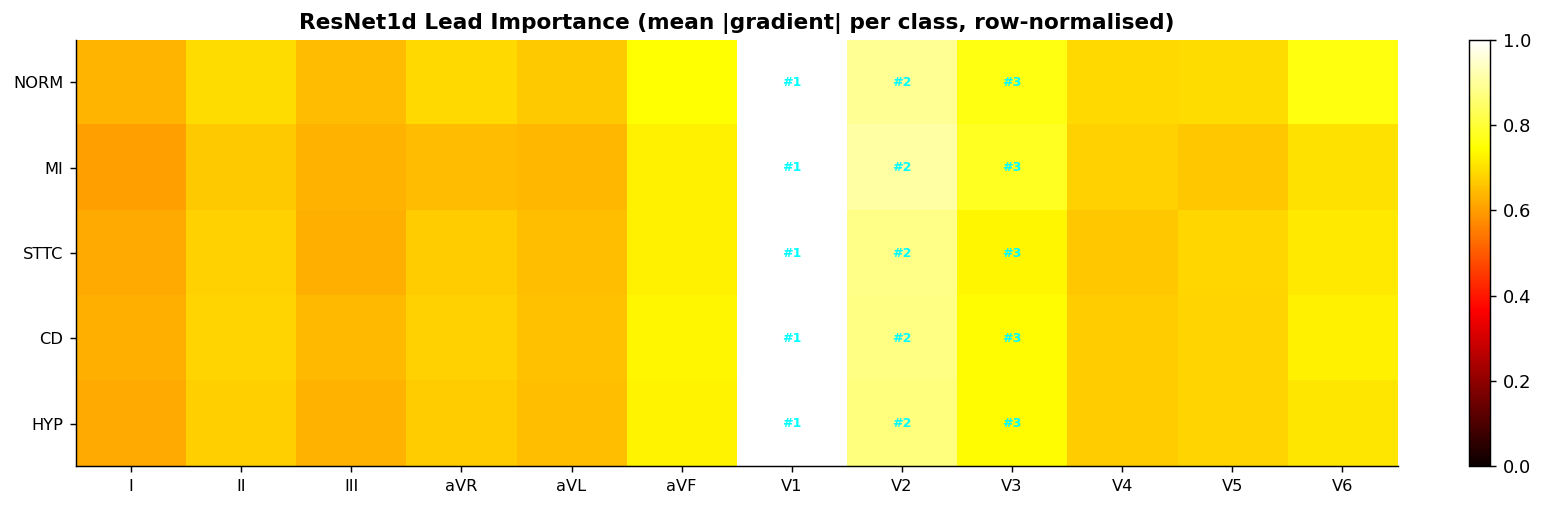

Top-3 leads per class (ResNet1d gradient attribution):
  NORM: ['V1', 'V2', 'V3']
  MI  : ['V1', 'V2', 'V3']
  STTC: ['V1', 'V2', 'V3']
  CD  : ['V1', 'V2', 'V3']
  HYP : ['V1', 'V2', 'V3']


In [45]:
# Lead importance via input gradients
lead_importance = np.zeros((N_CLASSES, N_CHANNELS), dtype=np.float64)
lead_counts     = np.zeros(N_CLASSES, dtype=np.float64)

model.eval()
for x, lbl in test_dl:
    x_t = x.to(DEVICE).requires_grad_(True)
    logits = model.resnet(x_t)
    pred_cls = logits.argmax(dim=1)
    score = logits[torch.arange(len(logits)), pred_cls].sum()
    score.backward()
    grads = x_t.grad.abs().mean(dim=-1).detach().cpu().numpy()  # (B, 12)
    for b in range(len(lbl)):
        c = lbl[b].item()
        lead_importance[c] += grads[b]
        lead_counts[c]     += 1

lead_importance /= (lead_counts[:, None] + 1e-8)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(lead_importance / (lead_importance.max(axis=1, keepdims=True) + 1e-8),
               aspect='auto', cmap='hot', vmin=0, vmax=1)
ax.set_xticks(range(N_CHANNELS)); ax.set_xticklabels(LEAD_NAMES, fontsize=9)
ax.set_yticks(range(N_CLASSES));  ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_title('ResNet1d Lead Importance (mean |gradient| per class, row-normalised)',
             fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.02)
for ci in range(N_CLASSES):
    row_n = lead_importance[ci] / (lead_importance[ci].max() + 1e-8)
    top3  = np.argsort(row_n)[::-1][:3]
    for rank, li in enumerate(top3):
        ax.text(li, ci, f'#{rank+1}', ha='center', va='center',
                fontsize=7, color='cyan', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/08c_lead_importance.png', bbox_inches='tight', dpi=110)
plt.show()

print('Top-3 leads per class (ResNet1d gradient attribution):')
for ci, name in enumerate(CLASS_NAMES):
    top3 = np.argsort(lead_importance[ci])[::-1][:3]
    print(f'  {name:4s}: {[LEAD_NAMES[i] for i in top3]}')


## Section 8 – Interpretability: Which Sensors Does the Model Trust?

**Grad-CAM + Lead Importance Analysis**

For each ECG, we ask: "Which of the 12 sensors (leads) did the model focus on?"

We use two methods:
1. **Grad-CAM**: Shows which TIME POINTS in each ECG were important
2. **Lead Importance**: Uses gradients to show which SENSORS (I, II, III, ...) matter most

This helps doctors understand: "Why did the model predict this patient has MI?"

In [46]:
# Clinical interpretations for each class
CLINICAL_NOTES = {
    'NORM': {
        'full'   : 'Normal ECG',
        'detail' : 'No significant diagnostic abnormality detected.',
        'leads'  : 'All leads within normal limits.',
    },
    'MI': {
        'full'   : 'Myocardial Infarction',
        'detail' : 'ST-segment elevation or Q-wave changes suggesting myocardial injury.',
        'leads'  : 'Most informative: V1-V6 (anterior MI), II/III/aVF (inferior MI).',
    },
    'STTC': {
        'full'   : 'ST/T-wave Change',
        'detail' : 'Non-specific ST or T-wave abnormality; consider ischaemia, LVH or drug effect.',
        'leads'  : 'Most informative: precordial leads V4-V6.',
    },
    'CD': {
        'full'   : 'Conduction Disturbance',
        'detail' : 'Bundle branch block or prolonged conduction interval detected.',
        'leads'  : 'Most informative: V1 (RBBB pattern), I/V6 (LBBB pattern).',
    },
    'HYP': {
        'full'   : 'Hypertrophy',
        'detail' : 'Voltage criteria or axis deviation suggesting ventricular hypertrophy.',
        'leads'  : 'Most informative: aVL (LVH), V1/V2 (RVH).',
    },
}

def generate_clinical_explanation(model, x_np, W, shap_layers,
                                   lead_importance_mat, device=DEVICE):
    """
    Generate a clinical text + numerical summary for one ECG.
    x_np: (12, T) numpy array (normalised signal)
    """
    x_t = torch.from_numpy(x_np).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        out   = model.forward_inference(x_t)
    probs     = F.softmax(out['logits'], dim=-1)[0].cpu().numpy()
    pred_cls  = int(probs.argmax())
    gate_val  = float(out['gate'][0].cpu())
    predicates = out['predicates'][0].cpu().numpy()
    pred_name  = CLASS_NAMES[pred_cls]
    conf       = float(probs[pred_cls])

    # Routing decision
    routing = ('Interpretable SBM (shapelet-based)'
               if gate_val > ETA_THRESHOLD
               else 'Deep ResNet1d expert')

    # Top shapelet feature
    si, ch, ki, contrib = get_best_feature(predicates, W, pred_cls)
    presence = 'PRESENT' if predicates[si * N_CHANNELS * K_SHAPELETS
                                        + ch * K_SHAPELETS + ki] > 0.5 else 'ABSENT'

    # Top lead for predicted class
    top_lead_idx  = int(np.argmax(lead_importance_mat[pred_cls]))
    top_lead_name = LEAD_NAMES[top_lead_idx]

    notes = CLINICAL_NOTES[pred_name]

    lines = [
        '─' * 58,
        f'  PREDICTED CLASS : {pred_name} — {notes["full"]}',
        f'  CONFIDENCE      : {conf*100:.1f}%',
        f'  ROUTING         : {routing}  (eta={gate_val:.3f})',
        '  ─ ─ ─',
        f'  CLINICAL DETAIL : {notes["detail"]}',
        f'  LEAD GUIDANCE   : {notes["leads"]}',
        f'  TOP SALIENT LEAD: {top_lead_name} (gradient attribution)',
        '  ─ ─ ─',
        f'  SHAPELET MATCH  : Scale {si+1}, Channel {ch+1} ({LEAD_NAMES[ch]}), '
        f'Shapelet #{ki+1}  [{presence}]',
        f'  SHAPELET WEIGHT : {contrib:.4f}  '
        f'({"supports" if contrib > 0 else "contradicts"} {pred_name})',
        '  ─ ─ ─',
        '  CLASS PROBABILITIES:',
    ]
    for ci, (name, p) in enumerate(zip(CLASS_NAMES, probs)):
        bar = '█' * int(p * 20)
        lines.append(f'    {name:4s}  {p*100:5.1f}%  {bar}')
    lines.append('─' * 58)
    return '\n'.join(lines)


# Demo: generate explanations for one correct prediction per class
print('=== InterpGN v10 — Clinical Text Explanations ===\n')
for ci in range(N_CLASSES):
    if explained[ci]:
        samp = explained[ci][0]
        txt = generate_clinical_explanation(
            model, samp['x_raw'], W, shap_layers, lead_importance)
        print(txt); print()


=== InterpGN v10 — Clinical Text Explanations ===

──────────────────────────────────────────────────────────
  PREDICTED CLASS : NORM — Normal ECG
  CONFIDENCE      : 65.9%
  ROUTING         : Deep ResNet1d expert  (eta=0.070)
  ─ ─ ─
  CLINICAL DETAIL : No significant diagnostic abnormality detected.
  LEAD GUIDANCE   : All leads within normal limits.
  TOP SALIENT LEAD: V1 (gradient attribution)
  ─ ─ ─
  SHAPELET MATCH  : Scale 1, Channel 11 (V5), Shapelet #2  [ABSENT]
  SHAPELET WEIGHT : 0.4928  (supports NORM)
  ─ ─ ─
  CLASS PROBABILITIES:
    NORM   65.9%  █████████████
    MI     14.8%  ██
    STTC    1.7%  
    CD     17.6%  ███
    HYP     0.0%  
──────────────────────────────────────────────────────────

──────────────────────────────────────────────────────────
  PREDICTED CLASS : MI — Myocardial Infarction
  CONFIDENCE      : 57.7%
  ROUTING         : Deep ResNet1d expert  (eta=0.101)
  ─ ─ ─
  CLINICAL DETAIL : ST-segment elevation or Q-wave changes suggesting myocardial

## Section 10 – Final Summary

In [47]:
print('='*65)
print('InterpGN v10 — Final Results')
print('='*65)
print(f'  Frequency mode         : {FREQ_HZ} Hz')
print(f'  Test Accuracy          : {test_acc:.4f}')
print(f'  Balanced Test Accuracy : {test_bal:.4f}')
print(f'  Macro AUC (OvR)        : {macro_auc:.4f}')
print()
print('  Training summary:')
print(f'    Phase 0 (SBM pre-train)    : {N_EPOCHS_PRE_SBM} epochs')
print(f'    Phase 0b (ResNet pre-train): {N_EPOCHS_PRE_FCN} epochs')
print(f'    Phase 1 (joint, actual)    : {es_joint.best_epoch+1} / {N_EPOCHS_JOINT} epochs')
print()
g_test, y_test_g = get_gate_stats(model, test_dl)
pct_int = (g_test > ETA_THRESHOLD).mean() * 100
print(f'  Expert routing (eta > {ETA_THRESHOLD}):')
print(f'    Interpretable (SBM)   : {pct_int:.1f}%')
print(f'    Deep (ResNet1d)       : {100-pct_int:.1f}%')
print()
print('  Per-class routing:')
for i, name in enumerate(CLASS_NAMES):
    vals = g_test[y_test_g == i]
    print(f'    {name:4s}  interpretable={((vals>ETA_THRESHOLD).mean()*100):.1f}%  '
          f'mean_eta={vals.mean():.3f}')
print()
print('  v10 improvements over v9:')
print('    [1] ResNet1d replaces FCN-Wang (better accuracy, residual connections)')
print('    [2] Both 100 Hz and 500 Hz supported via FREQ_HZ switch')
print('    [3] Grad-CAM temporal saliency maps for ResNet1d')
print('    [4] Lead importance via gradient attribution per class')
print('    [5] Per-class ROC + Precision-Recall curves')
print('    [6] Clinical text explanation generator')
print('    [7] OneCycleLR for faster convergence')
print()
print('  Benchmark:')
print('    xresnet1d101 (Strodthoff 2020) : ~0.928 macro AUC')
print(f'    InterpGN v10 (ResNet1d)        : {macro_auc:.4f} macro AUC + full interpretability')
print()
print('  Saved outputs:')
for f in sorted(os.listdir(OUTPUTS_DIR)):
    if f.endswith(('.png','.pt')):
        print(f'    {OUTPUTS_DIR}/{f}')
print('='*65)


InterpGN v10 — Final Results
  Frequency mode         : 100 Hz
  Test Accuracy          : 0.6524
  Balanced Test Accuracy : 0.5989
  Macro AUC (OvR)        : 0.8649

  Training summary:
    Phase 0 (SBM pre-train)    : 30 epochs
    Phase 0b (ResNet pre-train): 25 epochs
    Phase 1 (joint, actual)    : 37 / 300 epochs

  Expert routing (eta > 0.5):
    Interpretable (SBM)   : 2.5%
    Deep (ResNet1d)       : 97.5%

  Per-class routing:
    NORM  interpretable=1.0%  mean_eta=0.154
    MI    interpretable=3.4%  mean_eta=0.153
    STTC  interpretable=1.4%  mean_eta=0.179
    CD    interpretable=6.0%  mean_eta=0.183
    HYP   interpretable=4.4%  mean_eta=0.188

  v10 improvements over v9:
    [1] ResNet1d replaces FCN-Wang (better accuracy, residual connections)
    [2] Both 100 Hz and 500 Hz supported via FREQ_HZ switch
    [3] Grad-CAM temporal saliency maps for ResNet1d
    [4] Lead importance via gradient attribution per class
    [5] Per-class ROC + Precision-Recall curves
    [6] Cl